# Part 0 — TIC-simplex to latent-sphere sensitivity and calibration

This notebook diagnoses a fixed, unregularized BCE baseline; it does **not** train or select a final model. The primary statistic measures the encoder from the **input TIC simplex** to the **unit direction of its canonical LayerNorm latent**. These are different manifolds: the input is a simplex, while the output is a sphere in the zero-mean hyperplane, not a second simplex.

Each analysis block contains a distribution plot and numerical statistics. Exact Jacobians provide the reference; Hutchinson and the library's three-step power iteration are audited separately. Calibration uses a fixed validation sample, never test spectra. Earlier test-based conclusions in this notebook were exploratory and have been replaced rather than carried over to the corrected geometry.

**Decision outputs:** spectral sensitivity distributions, a fixed baseline 95th-percentile threshold, initial weight scales, estimator error, and transform-specific evidence. A correlation on one baseline does not establish robustness after training.

In [1]:
import hashlib
import json
import os
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import display
from scipy.signal import find_peaks, peak_widths
from scipy.stats import spearmanr

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper import MSIAutoEncoderWrapper
from msi_autoencoder_wrapper.analysis.autoencoder.latent import sphere_geometry as geometry
from msi_autoencoder_wrapper.analysis.autoencoder.latent.sensitivity import (
    SensitivityDiagnostic, canonical_direction, exact_output_jacobian,
    metric_operators, operator_statistics, paired_direction_angles,
)
from msi_autoencoder_wrapper.training.criterions.autoencoder.regularization.contractive_loss import MSIContractiveLoss
from msi_autoencoder_wrapper.utils.logger import get_custom_logger
from msi_autoencoder_wrapper.visualization import resolve_theme
from msi_autoencoder_wrapper.visualization.metrics import plot_violin_with_points

logger = get_custom_logger("metric_comparison")

2026-09-05 23:12:30,557 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-05 23:12:30,560 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-09-05 23:12:30,570 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-09-05 23:12:30,572 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 22 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-09-05 23:12:30,573 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-09-05 23:12:30,574 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-05 23:12:30,595 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-09-05 23:12:30,730 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 16 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-09-05 23:12:30,732 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 20 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


## Configuration and calibration sample

Sampling is deterministic and preserves the persisted split assignments. The held-out test split is not loaded for calibration. All metrics use exactly the same spectrum IDs. Bootstrap intervals below are conditional, spectrum-level intervals for this one baseline and image; spatial dependence and variation between model seeds are not captured.

The saved baseline references an old scratch-workspace path. A checked symlink restores that path without changing the saved configuration. The notebook fails if that path already points somewhere else.

In [2]:
WORKSPACE = Path("data/kidney_workspace")
MODEL_CONTEXT = "kidney"
MODEL_NAME = "bce-baseline-20260905-01__task_000000"
CALIBRATION_SPLIT = "validation"
SAMPLE_SIZE = 300
BATCH_SIZE = 32
RANDOM_SEED = 42
BOOTSTRAP_REPLICATES = 1000
PROBE_COUNTS = (1, 4, 8, 16, 32, 64)
ESTIMATOR_REPEATS = 8
POWER_AUDIT_SIZE = 32
TRANSFORM_REPEATS = 8
AMPLITUDES = (0.0, 0.001, 0.01, 0.1, 0.5, 1.0)
HINGE_QUANTILE = 0.95
HINGE_ALPHA = 1.0
LAMBDA_REFERENCE = 1e-5  # Historical Euclidean spectral, penalized_space="u"; starting anchor only.
DEVICE = "cuda"
if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required: run with uv run --extra cu118 outside a GPU-restricted sandbox.")
ARTIFACT_DIR = Path("assets/experiments/autoencoder_architecture/notebooks/05_09_26_contractive_expaned/part_0_metric_comparison_results")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
torch.set_num_threads(min(4, os.cpu_count() or 1))
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
theme = resolve_theme(None)
theme.apply()

scratch = Path("/tmp/ms488923/msi-wrapper/bce-baseline-20260905-01/workspace")
if scratch.is_symlink() or scratch.exists():
    if scratch.resolve() != WORKSPACE.resolve():
        raise RuntimeError(f"Saved scratch path points to another workspace: {scratch}")
else:
    scratch.parent.mkdir(parents=True, exist_ok=True)
    scratch.symlink_to(WORKSPACE.resolve(), target_is_directory=True)

wrapper = MSIAutoEncoderWrapper(project_path=str(WORKSPACE), device=DEVICE)
wrapper.workspace.set_default_image_path(MODEL_CONTEXT)
loaded_config = wrapper.load_configuration(model_name=MODEL_NAME)
model = wrapper.active_model.to(DEVICE).eval()
device = next(model.parameters()).device
partitions = wrapper.active_dataset.create_partitions()
if CALIBRATION_SPLIT not in {"train", "validation"}:
    raise ValueError("Calibration must use train or validation, never test.")
partition = getattr(partitions, CALIBRATION_SPLIT)
all_ids = np.asarray(partitions.manifest.assignments[CALIBRATION_SPLIT])
rng = np.random.default_rng(RANDOM_SEED)
sample_indices = rng.choice(len(all_ids), size=min(SAMPLE_SIZE, len(all_ids)), replace=False)
sample_ids = all_ids[sample_indices]
sample_spectra = torch.stack([partition[int(index)][1] for index in sample_indices]).float()  # (N, M)
MSIContractiveLoss._validate_tic_simplex_inputs(sample_spectra)
# REMARK: Remove only floating-point TIC residuals, with no pseudocount or support change.
tic_residual = (sample_spectra.sum(dim=1) - 1).abs().max().item()  # ()
sample_spectra = sample_spectra / sample_spectra.sum(dim=1, keepdim=True)  # (N, M)
config_path = WORKSPACE / "models" / MODEL_CONTEXT / MODEL_NAME / "config" / "config.json"
saved_config = json.loads(config_path.read_text())
BIN_SPACING = float(saved_config["data"]["context"]["components"]["binner"]["parameters"]["bin_step"])
layer_norm = model.encoder.bottleneck_layer[-1]
gamma, beta = layer_norm.weight.detach(), layer_norm.bias.detach()

def encode_spaces(x):
    """Return canonical values and directions for a batch of model spectra."""
    return canonical_direction(model.encoder(x), gamma, beta)

def encode_direction(x):
    """Return the differentiable unit canonical direction, shape (B, D)."""
    return encode_spaces(x)[1]

def encode_canonical(x):
    """Return the training-compatible canonical latent, shape (B, D)."""
    return encode_spaces(x)[0]

logger.info("Calibration: model=%s split=%s N=%s M=%s device=%s", MODEL_NAME, CALIBRATION_SPLIT, *sample_spectra.shape, device)
print({"sample_size": len(sample_ids), "bins": sample_spectra.shape[1], "bin_spacing_mz": BIN_SPACING,
       "max_original_tic_residual": tic_residual, "zero_bin_fraction": float((sample_spectra == 0).float().mean()),
       "torch": torch.__version__, "device": str(device)})

2026-09-05 23:12:30,929 | INFO     | msi_autoencoder_wrapper.core.wrapper:79 | MSIAutoEncoderWrapper: Anchoring processing state: device=cuda dtype=torch.float32


2026-09-05 23:12:30,930 | INFO     | msi_autoencoder_wrapper.core.mixins.context_manager.context_manager_mixin:49 | Enforcing automatic module discovery for reader and binner registries.


2026-09-05 23:12:30,932 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.readers.strategies'.


2026-09-05 23:12:30,933 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-05 23:12:30,934 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


...

2026-09-05 23:13:33,414 | INFO     | msi_autoencoder_wrapper.models.datasets.annotations.manager:203 | Mapped annotation index: retained_rows=420649 retained_entries=10495756 coordinate_system=binner.


2026-09-05 23:13:33,578 | INFO     | msi_autoencoder_wrapper.models.datasets.annotations.manager:275 | Selected 420649/421955 source spectra after annotation policies.


/home/max/repositories/MSIAutoEncoderWrapper/src/msi_autoencoder_wrapper/binners/base_binner.py:46: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  intensity_tensor = torch.as_tensor(intensities, dtype=self.dtype)


2026-09-05 23:13:37,628 | INFO     | metric_comparison:74 | Calibration: model=bce-baseline-20260905-01__task_000000 split=validation N=300 M=1273 device=cuda:0


{'sample_size': 300, 'bins': 1273, 'bin_spacing_mz': 0.55, 'max_original_tic_residual': 2.384185791015625e-07, 'zero_bin_fraction': 0.5184943675994873, 'torch': '2.7.1+cu118', 'device': 'cuda:0'}


## Geometry and conventions

Let $z$ be the affine LayerNorm output, $H=I-\mathbf1\mathbf1^T/D$, $u=(z-\beta)/\gamma$, $r=\|Hu\|$, and $q=Hu/r$. Then

$$J_q=\frac{I-qq^T}{r}H\operatorname{diag}(\gamma)^{-1}J_z.$$

The output tangent projector is $H-qq^T$. For $D=10$, $q\in S^8\subset\mathbf1^\perp\subset\mathbb R^{10}$ and the tangent rank is at most eight. Differentiating **the actual normalized direction** includes this projector and the angular scale automatically. The `eps` in LayerNorm makes $\|u\|=\sqrt D$ approximate; it must not be substituted blindly when measuring small angles. Angles use actual unit directions and a stable half-angle formula, in radians internally and degrees only for display.

For the input $x\in\Delta^{M-1}$, $\mathbf1^T\delta=0$. We use the Fisher convention $\|\delta\|_F^2=\sum_i\delta_i^2/x_i$, without an extra factor of four. With $P_x=I-\sqrt x\sqrt x^T$,

$$A_F=J_q\operatorname{diag}(\sqrt x)P_x,\qquad
 B_F=A_FA_F^T=J_q[\operatorname{diag}(x)-xx^T]J_q^T.$$

The implementation reuses `ContractiveLoss`'s Fisher adjoint. No $M\times M$ matrix is formed. At zero bins it gives a fixed-support tangent limit; it does not assign finite local Fisher length to arbitrary perturbations introducing mass into empty bins. Finite `mz_shift` remains an empirical robustness check, not a Fisher-local bound in those directions.

For each quadratic geometry, $F_g^2=\operatorname{tr}B_g$ and $s_g^2=\lambda_{\max}(B_g)$. $F_g$ measures aggregate sensitivity; $s_g$ is the maximum local stretch. Their numerical scales depend on the input metric and must not be ranked as if a smaller value alone meant a better geometry.

Two output conventions are retained: **angular** ($J_q$, primary) and **canonical_u** ($J_u$, compatibility with the current training loss). They are not interchangeable configuration values.

In [3]:
with torch.no_grad():
    baseline_batches = [encode_spaces(sample_spectra[start:start+BATCH_SIZE].to(device))
                        for start in range(0, len(sample_ids), BATCH_SIZE)]
    baseline_u = torch.cat([values[0] for values in baseline_batches])  # (N, D)
    baseline_q = torch.cat([values[1] for values in baseline_batches])  # (N, D)
geometry_report = geometry.verify_canonicalization(baseline_u.cpu().numpy())
geometry_report.update({"latent_dimension": baseline_q.shape[1], "expected_tangent_rank": baseline_q.shape[1] - 2,
                       "max_unit_norm_residual": float((baseline_q.norm(dim=1) - 1).abs().max()),
                       "max_zero_mean_residual": float(baseline_q.mean(dim=1).abs().max())})
display(pd.Series(geometry_report, name="geometry_checks"))

max_abs_row_sum           7.152557e-07
expected_norm             3.162278e+00
mean_row_norm             3.162275e+00
max_abs_norm_deviation    5.245209e-06
latent_dimension          1.000000e+01
expected_tangent_rank     8.000000e+00
max_unit_norm_residual    1.192093e-07
max_zero_mean_residual    1.788139e-08
Name: geometry_checks, dtype: float64

## Empirical bandwidth and secondary input geometries

`peak_widths(rel_height=0.5)` measures width at half **prominence**, not necessarily FWHM. We report its distribution and use median width / $2\sqrt{2\log 2}$ only as a Gaussian-width proxy for the discretized spectrum. One-bin peaks do not resolve the instrument's continuous peak width. No instrument-resolution claim follows from this estimate.

Cramer uses $\|\delta\|_{Cr}^2=h\sum_{i=1}^{M-1}(\sum_{j\leq i}\delta_j)^2$ on zero-sum perturbations, where $h$ is the bin spacing. Thus its adjoint is the adjacent Jacobian difference divided by $\sqrt h$. It is a quadratic CDF metric, not identical to a Wasserstein reconstruction loss.

Gaussian is an exploratory smooth perturbation operator $P K_\sigma P$, with $P=I-\mathbf1\mathbf1^T/M$, a symmetric zero-padded convolution, and projection on both sides. It is not labelled "linearized Sinkhorn" without a derivation. The comparison includes Euclidean ambient and simplex variants, and Fisher diagonal and simplex variants to isolate the projection effect.

Sources: [LayerNorm](https://docs.pytorch.org/docs/2.7/generated/torch.nn.LayerNorm.html), [peak_widths](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.peak_widths.html).

,half_prominence_width_bins
count,46890.000000
mean,1.129500
std,0.347045
min,0.579796
25%,1.000000
50%,1.000000
75%,1.105123
90%,1.444900
95%,1.772292
99%,2.610426


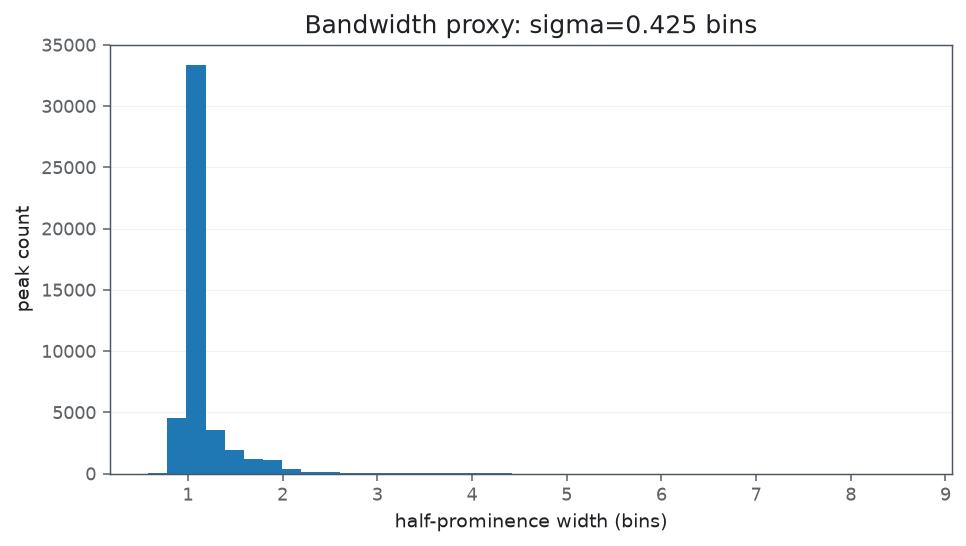

In [4]:
peak_rows = []
for spectrum_id, spectrum in zip(sample_ids, sample_spectra.numpy()):
    peaks, _ = find_peaks(spectrum, prominence=max(float(spectrum.mean()), 0.0))
    if peaks.size:
        widths = peak_widths(spectrum, peaks, rel_height=0.5)[0]  # (number_of_peaks,)
        peak_rows.extend({"spectrum_id": int(spectrum_id), "half_prominence_width_bins": float(value)} for value in widths if np.isfinite(value) and value > 0)
peak_frame = pd.DataFrame(peak_rows)
if peak_frame.empty:
    raise ValueError("No valid peaks for empirical bandwidth calibration.")
gaussian_sigma_bins = float(peak_frame.half_prominence_width_bins.median() / np.sqrt(8 * np.log(2)))

def gaussian_kernel_for(sigma):
    """Build a finite symmetric unit-sum Gaussian kernel in bin coordinates."""
    radius = max(1, int(np.ceil(3 * sigma)))
    positions = torch.arange(-radius, radius + 1, dtype=torch.float64, device=device)
    weights = torch.exp(-0.5 * (positions / sigma).square())  # (2*radius+1,)
    return weights / weights.sum()

gaussian_kernel = gaussian_kernel_for(gaussian_sigma_bins)
display(peak_frame[["half_prominence_width_bins"]].describe(percentiles=[.25, .5, .75, .9, .95, .99]))
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(peak_frame.half_prominence_width_bins, bins=40)
ax.set(xlabel="half-prominence width (bins)", ylabel="peak count", title=f"Bandwidth proxy: sigma={gaussian_sigma_bins:.3g} bins")
fig.tight_layout()
plt.show()

## Exact per-spectrum norms — distributions first

One Jacobian per output convention is computed per batch using ten reverse-mode passes. The angular Jacobian uses the corrected output map; the canonical Jacobian is retained as the historical training reference. Each input operator is applied to these same derivatives. Only $D\times D$ Gram matrices are diagonalized, with float64 accumulation. Material negative eigenvalues cause an error; only roundoff-scale negatives are clipped.

The main table stores squared norms **and** norms with explicit column names. The exact $W_1\to\ell_2$ local operator norm on a uniform one-dimensional grid is additionally $\max_i\|J_{q,:,i+1}-J_{q,:,i}\|_2/h$. It replaces the old arbitrary mean of `max_w1_dual` over random latent probes and is shown separately.

In [5]:
metric_rows, jacobian_batches, gram_batches = [], [], {}
for start in range(0, len(sample_ids), BATCH_SIZE):
    batch = sample_spectra[start:start+BATCH_SIZE].to(device).requires_grad_(True)  # (B, M)
    u, q = encode_spaces(batch)  # (B, D), (B, D)
    for output_space, outputs in (("angular", q), ("canonical_u", u)):
        jacobian = exact_output_jacobian(outputs, batch).double()  # (B, D, M)
        operators = metric_operators(jacobian, batch.detach().double(), gaussian_kernel, BIN_SPACING)
        if output_space == "angular":
            jacobian_batches.append(jacobian.cpu())
        for name, operator in operators.items():
            gram, frobenius_squared, spectral_squared = operator_statistics(operator)
            if output_space == "angular":
                gram_batches.setdefault(name, []).append(gram.cpu())
            for row_index in range(batch.shape[0]):
                metric_rows.append({"spectrum_id": int(sample_ids[start+row_index]), "output_space": output_space,
                                    "input_geometry": name, "frobenius_squared": float(frobenius_squared[row_index]),
                                    "spectral_squared": float(spectral_squared[row_index])})
    logger.info("Exact diagnostics: %s/%s spectra", min(start+BATCH_SIZE, len(sample_ids)), len(sample_ids))
    del batch, u, q, outputs, jacobian, operators, operator, gram
metric_frame = pd.DataFrame(metric_rows)
metric_frame["frobenius_norm"] = np.sqrt(metric_frame.frobenius_squared)
metric_frame["spectral_norm"] = np.sqrt(metric_frame.spectral_squared)
metric_frame["stable_rank"] = metric_frame.frobenius_squared.div(metric_frame.spectral_squared.where(metric_frame.spectral_squared > 0))
angular_jacobian = torch.cat(jacobian_batches)  # (N, D, M), CPU float64
angular_grams = {name: torch.cat(batches) for name, batches in gram_batches.items()}  # each (N, D, D)
radial_residual = torch.einsum("nd,ndm->nm", baseline_q.double().cpu(), angular_jacobian).norm(dim=1)  # (N,)
constant_residual = angular_jacobian.sum(dim=1).norm(dim=1)  # (N,)
jacobian_scale = angular_jacobian.norm(dim=(1, 2)).clamp_min(torch.finfo(torch.float64).tiny)  # (N,)
geometry_report.update({"max_relative_radial_jacobian_residual": float((radial_residual/jacobian_scale).max()),
                        "max_relative_constant_jacobian_residual": float((constant_residual/jacobian_scale).max())})
# Float32 encoder differentiation, with float64 Gram accumulation.
if max(geometry_report["max_relative_radial_jacobian_residual"], geometry_report["max_relative_constant_jacobian_residual"]) > 1e-5:
    raise ValueError("Angular Jacobian does not satisfy the output tangent constraints.")
display(pd.Series(geometry_report, name="geometry_checks_with_jacobian"))
angular_frame = metric_frame.query("output_space == 'angular'").copy()
GEOMETRIES = list(angular_grams)
spectral_wide = angular_frame.pivot(index="spectrum_id", columns="input_geometry", values="spectral_norm").reindex(sample_ids)
frobenius_wide = angular_frame.pivot(index="spectrum_id", columns="input_geometry", values="frobenius_norm").reindex(sample_ids)
w1_norm = torch.linalg.vector_norm(torch.diff(angular_jacobian, dim=-1), dim=1).amax(dim=1).numpy() / BIN_SPACING  # (N,)

2026-09-05 23:13:39,371 | INFO     | metric_comparison:18 | Exact diagnostics: 32/300 spectra


2026-09-05 23:13:39,633 | INFO     | metric_comparison:18 | Exact diagnostics: 64/300 spectra


2026-09-05 23:13:39,806 | INFO     | metric_comparison:18 | Exact diagnostics: 96/300 spectra


2026-09-05 23:13:39,991 | INFO     | metric_comparison:18 | Exact diagnostics: 128/300 spectra


2026-09-05 23:13:40,198 | INFO     | metric_comparison:18 | Exact diagnostics: 160/300 spectra


...

2026-09-05 23:13:40,528 | INFO     | metric_comparison:18 | Exact diagnostics: 224/300 spectra


2026-09-05 23:13:40,692 | INFO     | metric_comparison:18 | Exact diagnostics: 256/300 spectra


2026-09-05 23:13:40,854 | INFO     | metric_comparison:18 | Exact diagnostics: 288/300 spectra


2026-09-05 23:13:40,979 | INFO     | metric_comparison:18 | Exact diagnostics: 300/300 spectra


max_abs_row_sum                            7.152557e-07
expected_norm                              3.162278e+00
mean_row_norm                              3.162275e+00
max_abs_norm_deviation                     5.245209e-06
latent_dimension                           1.000000e+01
expected_tangent_rank                      8.000000e+00
max_unit_norm_residual                     1.192093e-07
max_zero_mean_residual                     1.788139e-08
max_relative_radial_jacobian_residual      5.529707e-08
max_relative_constant_jacobian_residual    1.665778e-07
Name: geometry_checks_with_jacobian, dtype: float64

,input_geometry,statistic,n,nonfinite,zeros,q25,median,q75,q90,q95,q99,mean,std,iqr,min,max,median_ci_low,median_ci_high,q95_ci_low,q95_ci_high
0,euclidean_ambient,frobenius_norm,300,0,0,97.089102,113.779835,133.660559,155.010436,159.481736,180.085825,118.312597,24.213745,36.571457,74.759591,191.772997,107.354069,123.608440,156.805357,164.678422
1,euclidean_simplex,frobenius_norm,300,0,0,97.089102,113.779835,133.660559,155.010436,159.481736,180.085825,118.312597,24.213745,36.571457,74.759591,191.772997,107.354069,123.608440,156.805357,164.678422
2,fisher_diagonal,frobenius_norm,300,0,0,2.678629,3.006033,3.610286,4.046665,4.244258,4.414727,3.108192,0.648495,0.931656,1.768651,4.504582,2.940005,3.044821,4.167092,4.308983
3,fisher_simplex,frobenius_norm,300,0,0,2.675143,3.003946,3.607334,4.045269,4.240550,4.411473,3.105351,0.648449,0.932190,1.766524,4.502248,2.937455,3.042665,4.164494,4.306004
4,cramer_simplex,frobenius_norm,300,0,0,113.563364,141.765152,162.463845,173.614591,186.023707,212.368928,141.117768,29.268170,48.900481,92.460238,273.328148,137.717901,145.638394,177.213096,198.837614
5,gaussian_simplex,frobenius_norm,300,0,0,93.489951,108.992722,128.132148,149.223556,154.026425,169.069519,113.523549,23.492603,34.642197,71.542492,185.194571,101.647716,117.404044,151.964334,159.007339
6,euclidean_ambient,spectral_norm,300,0,0,54.117797,65.810661,78.894832,88.819946,93.787608,125.301931,67.944994,16.717396,24.777035,40.554861,136.671424,63.375025,67.588989,90.946528,101.810122
7,euclidean_simplex,spectral_norm,300,0,0,54.117797,65.810661,78.894832,88.819946,93.787608,125.301931,67.944994,16.717396,24.777035,40.554861,136.671424,63.375025,67.588989,90.946528,101.810122
8,fisher_diagonal,spectral_norm,300,0,0,1.409013,1.536737,1.859889,2.154970,2.228881,2.452099,1.625884,0.351129,0.450876,0.901150,2.861595,1.513693,1.573599,2.177273,2.310742
9,fisher_simplex,spectral_norm,300,0,0,1.406721,1.536702,1.857798,2.151943,2.225414,2.447474,1.623555,0.350966,0.451077,0.898341,2.850820,1.512326,1.572112,2.172783,2.307819


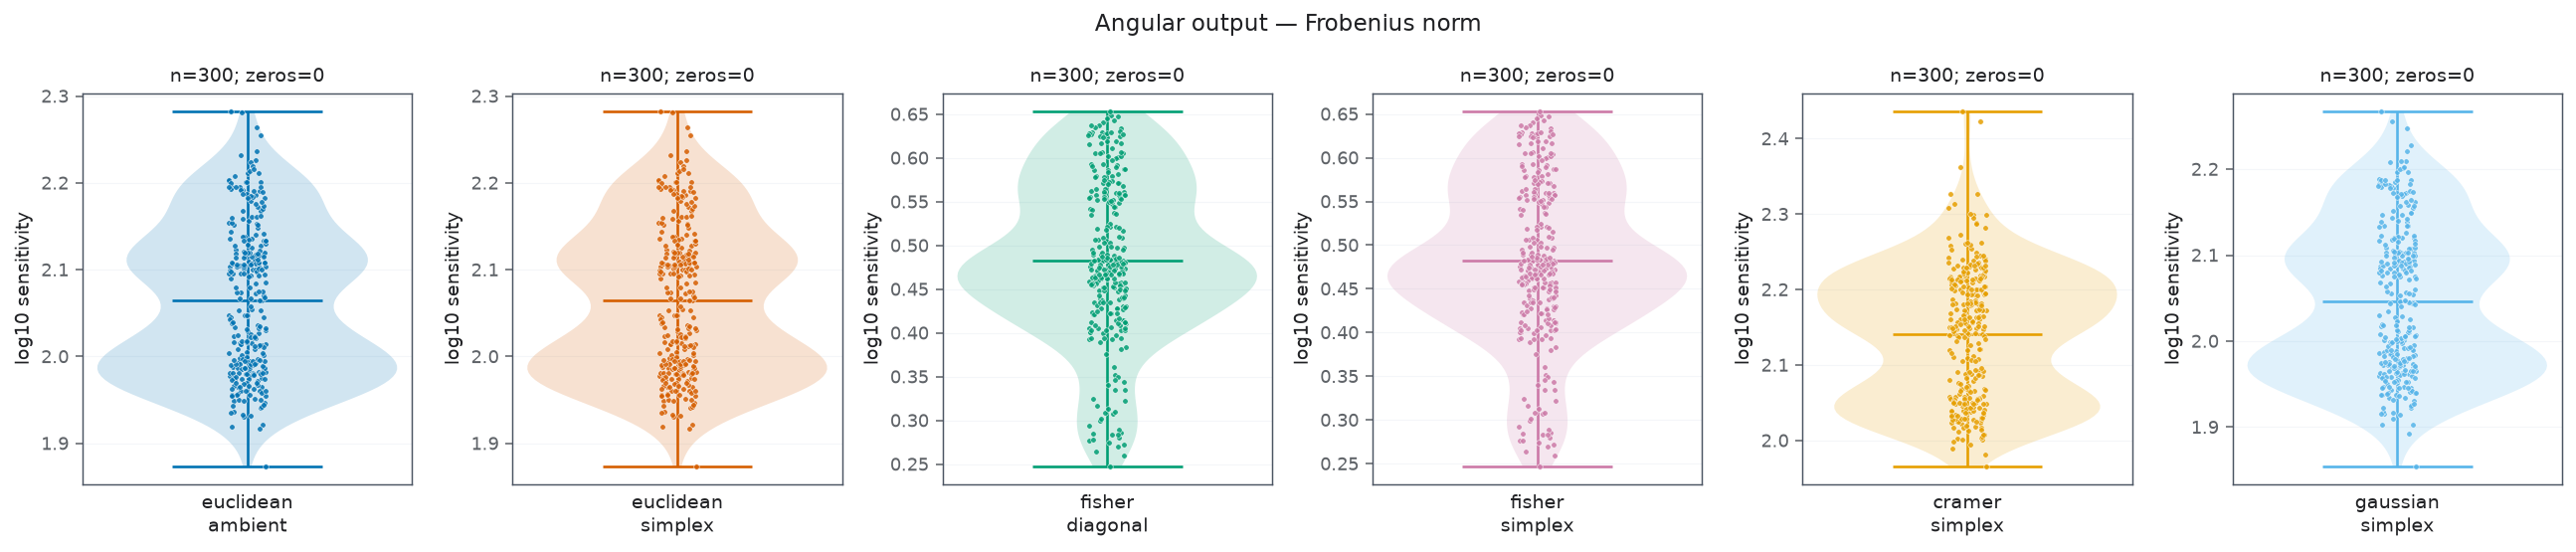

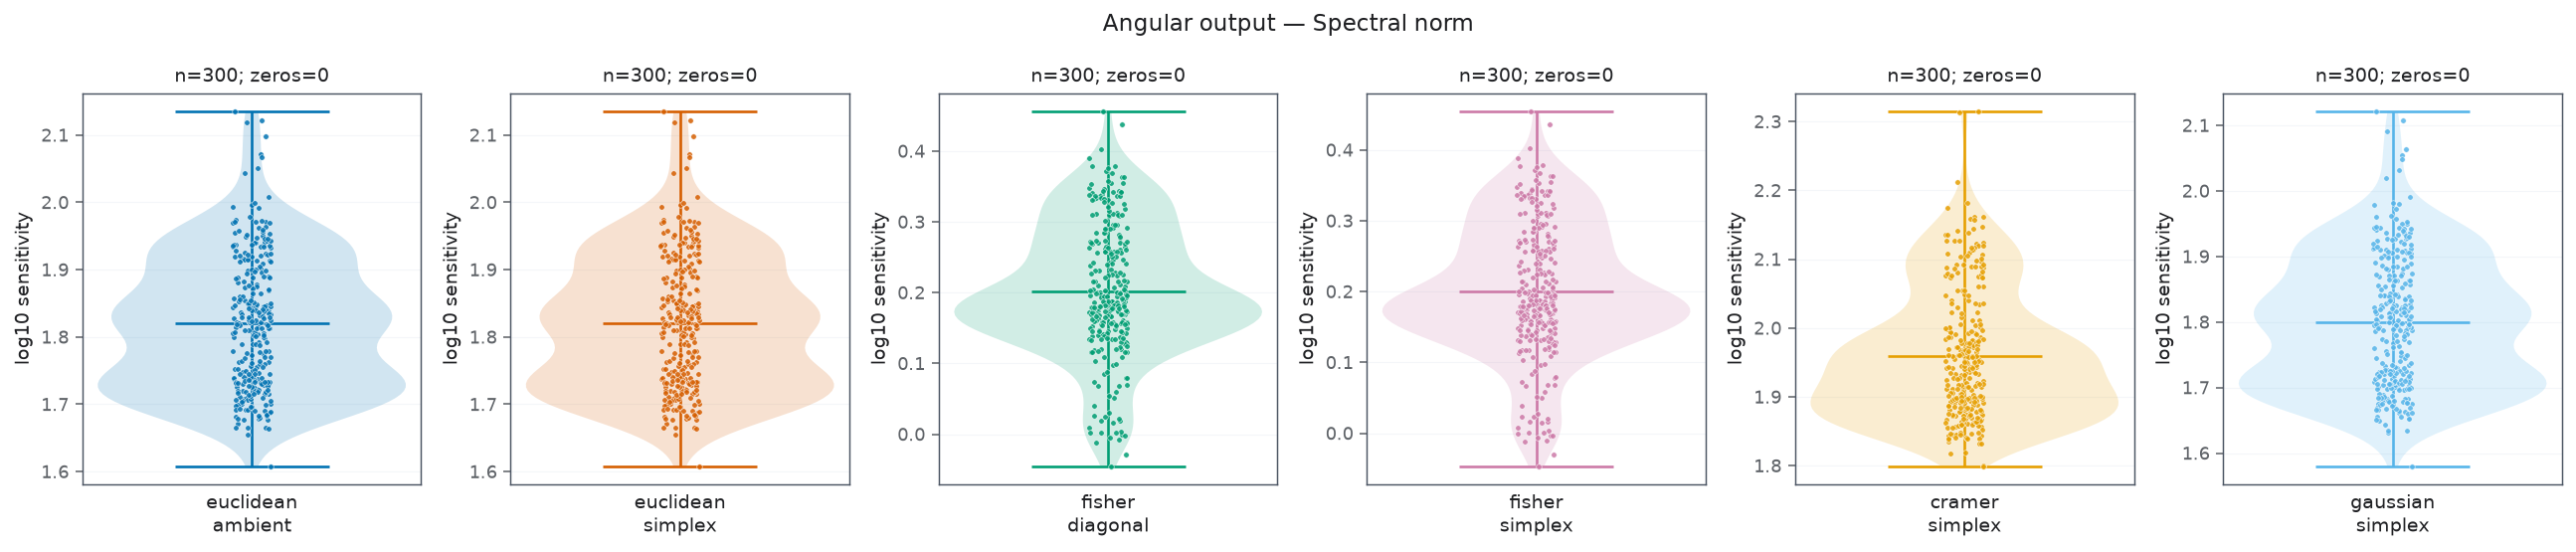

,n,nonfinite,zeros,q25,median,q75,q90,q95,q99,mean,std,iqr,min,max,median_ci_low,median_ci_high,q95_ci_low,q95_ci_high
exact_w1_to_angular_norm,300,0,0,19.663087,22.949279,28.976011,42.806698,45.456547,52.5326,25.913611,9.285191,9.312925,13.069901,57.460058,21.957496,23.950356,43.466973,47.234584


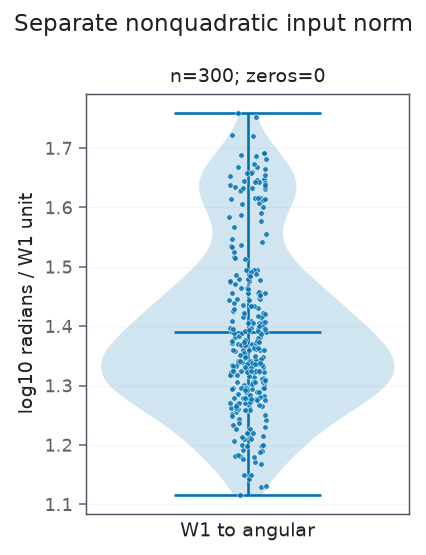

In [6]:
def distribution_summary(values):
    """Summarize finite samples and conditional bootstrap quantile uncertainty."""
    values = np.asarray(values, dtype=float)
    finite = values[np.isfinite(values)]
    result = {"n": len(values), "nonfinite": int((~np.isfinite(values)).sum()), "zeros": int((finite == 0).sum())}
    if not len(finite):
        return result
    quantiles = np.quantile(finite, [.25, .5, .75, .9, .95, .99])
    result.update(dict(zip(["q25", "median", "q75", "q90", "q95", "q99"], quantiles)))
    result.update(mean=float(finite.mean()), std=float(finite.std(ddof=1)) if len(finite) > 1 else np.nan,
                  iqr=float(quantiles[2]-quantiles[0]), min=float(finite.min()), max=float(finite.max()))
    generator = np.random.default_rng(RANDOM_SEED + 101)
    bootstrap = finite[generator.integers(len(finite), size=(BOOTSTRAP_REPLICATES, len(finite)))]  # (R, N)
    for label, quantile in (("median", .5), ("q95", .95)):
        lower, upper = np.quantile(np.quantile(bootstrap, quantile, axis=1), [.025, .975])
        result.update({f"{label}_ci_low": lower, f"{label}_ci_high": upper})
    return result


def distribution_panels(groups, title, ylabel, logarithmic=False, save_name=None):
    """Draw per-group violins and points without hiding zeros or mixing scales."""
    fig, axes = plt.subplots(1, len(groups), figsize=(3.1*len(groups), 4), squeeze=False)
    for index, ((name, values), ax) in enumerate(zip(groups.items(), axes.flat)):
        values = np.asarray(values, dtype=float)
        finite = values[np.isfinite(values)]
        if len(finite) and np.ptp(finite) > 0:
            # REMARK: Estimate density in log coordinates when displaying log data.
            positive = finite[finite > 0] if logarithmic else finite
            if len(positive) > 1 and np.ptp(positive) > 0:
                plotted = np.log10(positive) if logarithmic else positive
                plot_violin_with_points(plotted, position=0, ax=ax, color=theme.color_for_model(name, index), theme=theme, point_size=8)
            else:
                ax.scatter(np.zeros(len(positive)), np.log10(positive) if logarithmic else positive)
        elif len(finite) and (not logarithmic or finite[0] > 0):
            ax.scatter([0], [np.log10(finite[0]) if logarithmic else finite[0]])
        ax.set(xticks=[], xlabel=name.replace("_", "\n"), ylabel=("log10 " if logarithmic else "") + ylabel)
        ax.set_title(f"n={len(finite)}; zeros={int((finite == 0).sum())}", fontsize=10)
        # Avoid visually magnifying roundoff or near-constant ratios.
        lower, upper = ax.get_ylim()
        if upper - lower < .02:
            midpoint = (lower + upper) / 2
            ax.set_ylim(midpoint-.01, midpoint+.01)
        ax.ticklabel_format(axis="y", useOffset=False)
        ax.grid(alpha=.2)
    fig.suptitle(title)
    fig.tight_layout()
    if save_name is not None:
        fig.savefig(ARTIFACT_DIR / save_name, dpi=160, bbox_inches="tight")
    plt.show()

summary_frame = pd.DataFrame([
    {"input_geometry": name, "statistic": statistic, **distribution_summary(frame[name])}
    for statistic, frame in (("frobenius_norm", frobenius_wide), ("spectral_norm", spectral_wide))
    for name in GEOMETRIES
])
display(summary_frame)
for statistic, frame in (("Frobenius norm", frobenius_wide), ("Spectral norm", spectral_wide)):
    distribution_panels({name: frame[name] for name in GEOMETRIES}, f"Angular output — {statistic}", "sensitivity", logarithmic=True,
                        save_name=f"{statistic.split()[0].lower()}_distributions.png")
display(pd.DataFrame([distribution_summary(w1_norm)], index=["exact_w1_to_angular_norm"]))
distribution_panels({"W1 to angular": w1_norm}, "Separate nonquadratic input norm", "radians / W1 unit", logarithmic=True)

## Projection effects, scale ratios and ranking

Projection effects are paired on the same spectra. Fisher-simplex / Fisher-diagonal and Euclidean-simplex / Euclidean-ambient isolate the input constraint. Fisher-simplex / Euclidean-simplex combines geometry and scale. Output angular / canonical-u ratios quantify the output change separately.

A **ratio of means**, a **ratio of medians**, and a **median of paired ratios** are different summaries. None is substituted silently for another. Undefined ratios (zero denominator) are counted. The stable rank $F_g^2/s_g^2$ is between 1 and the operator rank for nonzero operators; angular rank is at most $D-2$ up to numerical residuals.

,ratio,n,nonfinite,zeros,q25,median,q75,q90,q95,q99,mean,std,iqr,min,max,median_ci_low,median_ci_high,q95_ci_low,q95_ci_high
0,F simplex / F diagonal,300,0,0,0.997497,0.999326,0.999931,0.999982,0.999997,1.000000,0.998487,1.700616e-03,2.433632e-03,0.993981,1.000000,0.998746,0.999657,0.999991,0.999998
1,E simplex / E ambient,300,0,0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.900655e-16,4.440892e-16,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,F simplex / E simplex,300,0,0,0.021331,0.025952,0.028017,0.029498,0.030064,0.031530,0.024518,4.677284e-03,6.685342e-03,0.011585,0.032802,0.025345,0.026413,0.029660,0.030458
3,angular / canonical u (F),300,0,0,0.316228,0.316228,0.316228,0.316228,0.316228,0.316228,0.316228,1.173345e-07,2.156427e-07,0.316228,0.316228,0.316228,0.316228,0.316228,0.316228


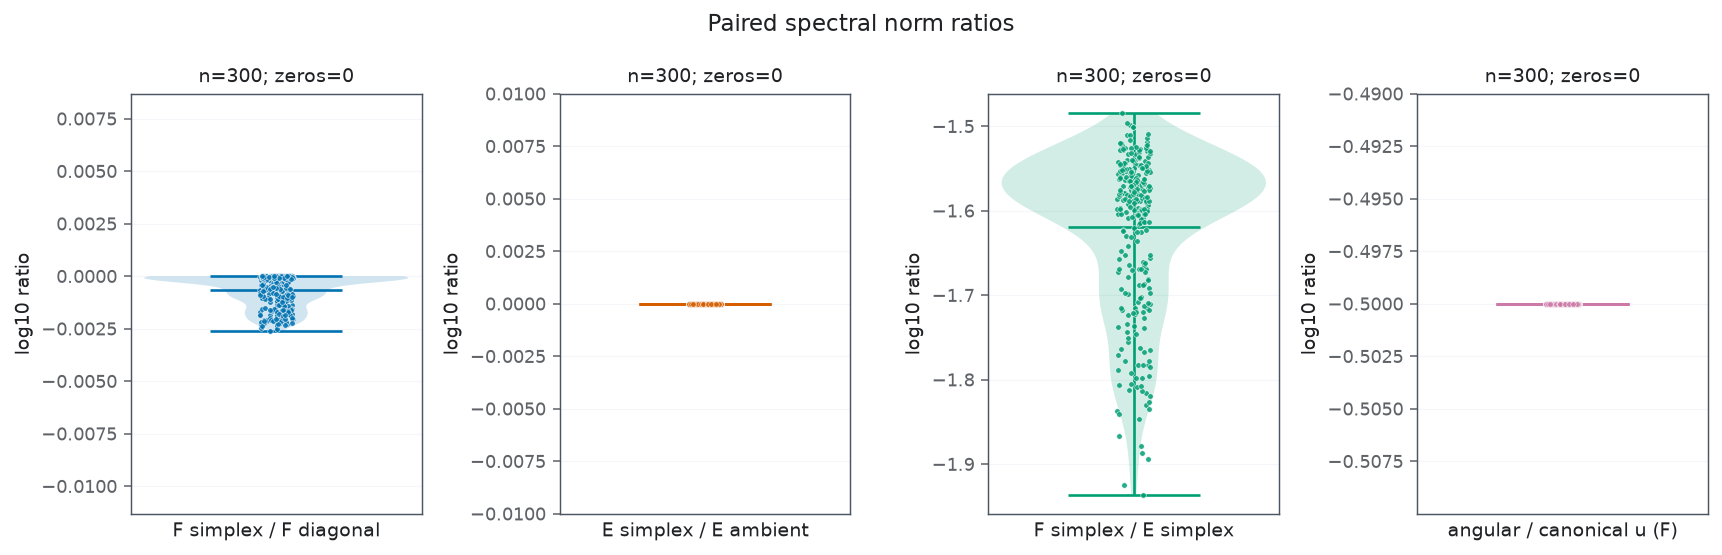

input_geometry,cramer_simplex,euclidean_ambient,euclidean_simplex,fisher_diagonal,fisher_simplex,gaussian_simplex
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,2.382145,3.120167,3.120167,3.691200,3.694837,3.151242
std,0.658683,0.500372,0.500372,0.465888,0.462983,0.481992
min,1.573050,1.930253,1.930253,2.168861,2.177304,1.902372
25%,1.903087,2.783211,2.783211,3.457355,3.461811,2.842908
50%,2.085904,3.217435,3.217435,3.762085,3.769416,3.267655
75%,2.875888,3.478132,3.478132,3.971413,3.974970,3.489967
max,4.434260,4.111186,4.111186,4.722799,4.718996,4.046846


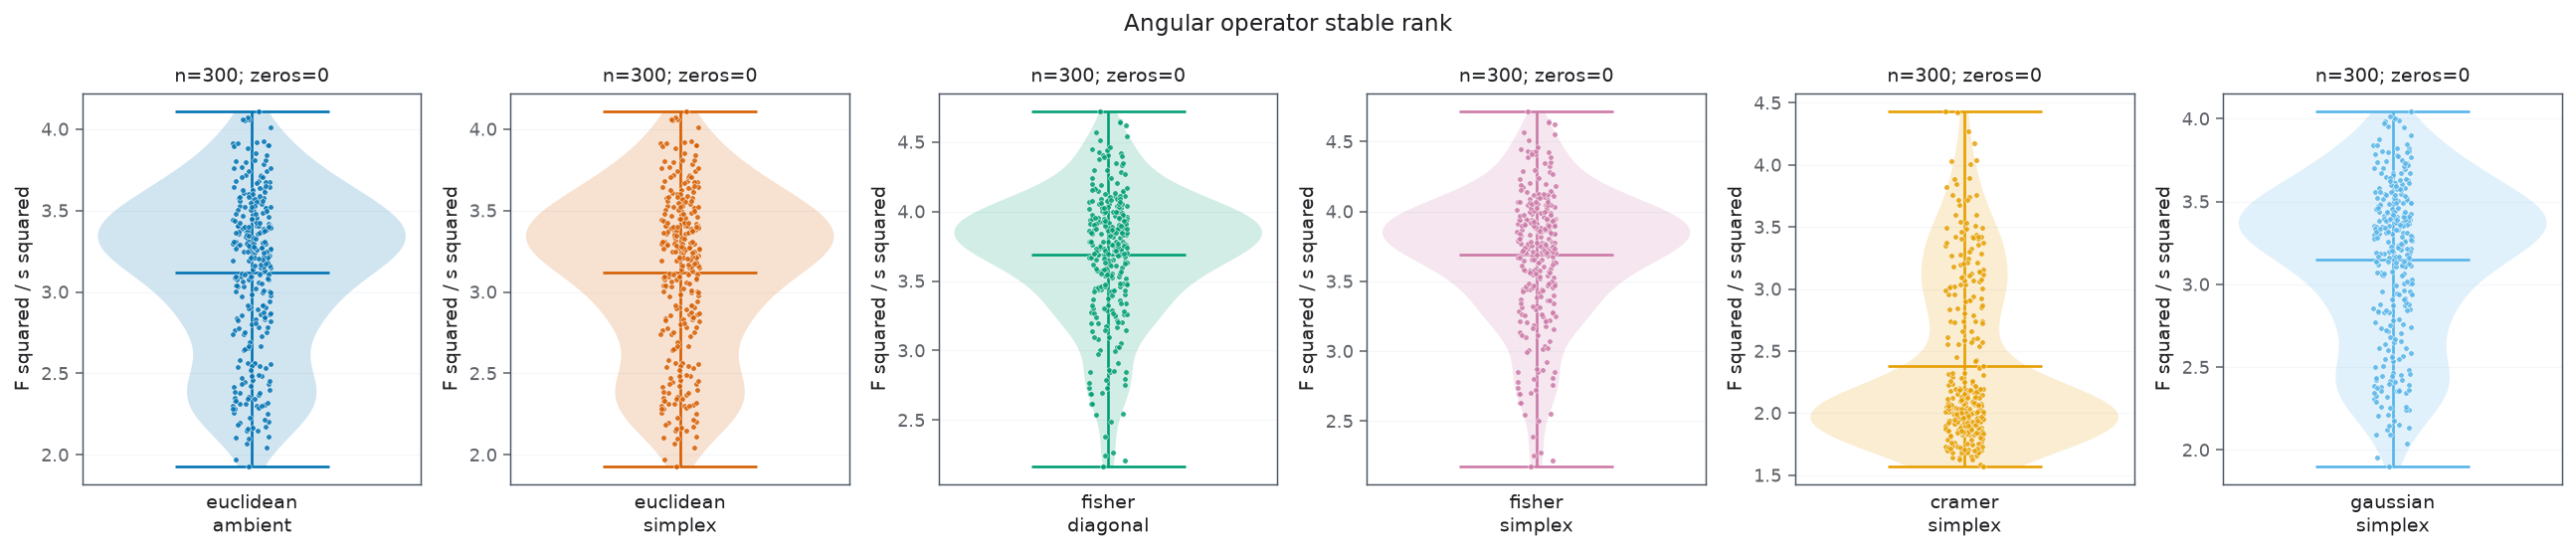

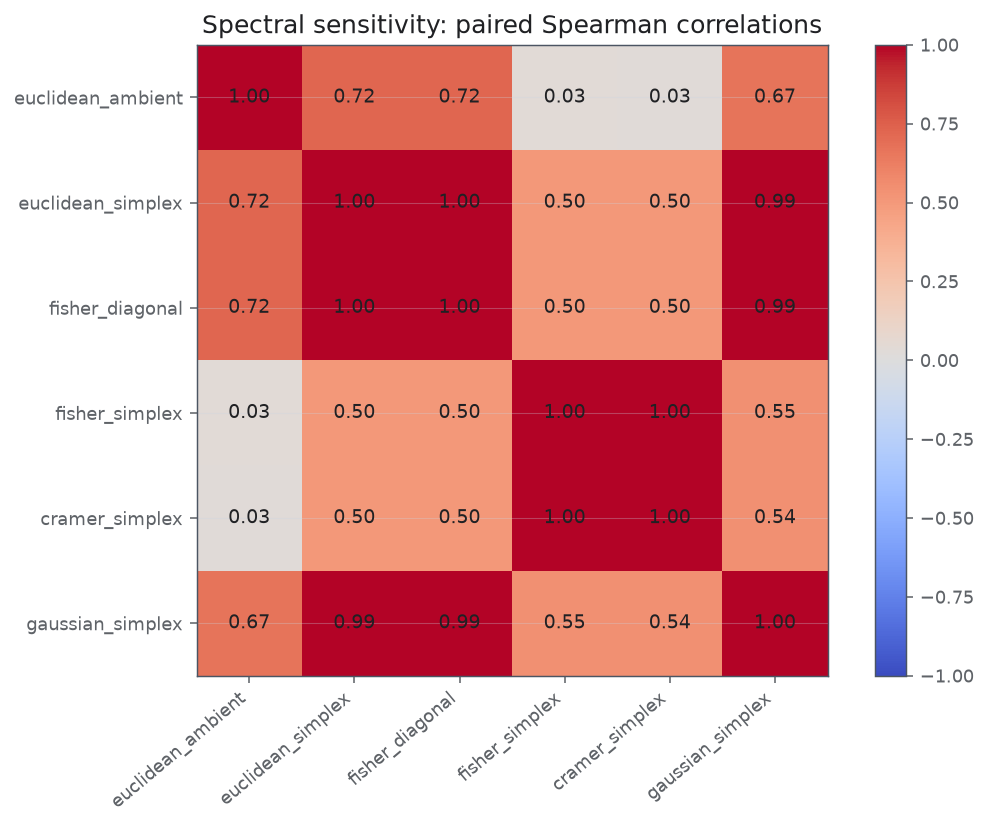

In [7]:
ratio_groups = {
    "F simplex / F diagonal": spectral_wide.fisher_simplex / spectral_wide.fisher_diagonal.where(spectral_wide.fisher_diagonal > 0),
    "E simplex / E ambient": spectral_wide.euclidean_simplex / spectral_wide.euclidean_ambient.where(spectral_wide.euclidean_ambient > 0),
    "F simplex / E simplex": spectral_wide.fisher_simplex / spectral_wide.euclidean_simplex.where(spectral_wide.euclidean_simplex > 0),
}
u_wide = metric_frame.query("output_space == 'canonical_u'").pivot(index="spectrum_id", columns="input_geometry", values="spectral_norm").reindex(sample_ids)
ratio_groups["angular / canonical u (F)"] = spectral_wide.fisher_simplex / u_wide.fisher_simplex.where(u_wide.fisher_simplex > 0)
ratio_summary = pd.DataFrame([{ "ratio": name, **distribution_summary(values)} for name, values in ratio_groups.items()])
display(ratio_summary)
distribution_panels(ratio_groups, "Paired spectral norm ratios", "ratio", logarithmic=True)
rank_frame = angular_frame.pivot(index="spectrum_id", columns="input_geometry", values="stable_rank")
display(rank_frame.describe())
distribution_panels({name: rank_frame[name] for name in GEOMETRIES}, "Angular operator stable rank", "F squared / s squared")
correlation_matrix = spectral_wide.corr(method="spearman")
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(correlation_matrix, vmin=-1, vmax=1, cmap="coolwarm")
ax.set(xticks=range(len(GEOMETRIES)), yticks=range(len(GEOMETRIES)), xticklabels=GEOMETRIES, yticklabels=GEOMETRIES,
       title="Spectral sensitivity: paired Spearman correlations")
plt.setp(ax.get_xticklabels(), rotation=40, ha="right")
for row in range(len(GEOMETRIES)):
    for col in range(len(GEOMETRIES)):
        ax.text(col, row, f"{correlation_matrix.iloc[row, col]:.2f}", ha="center", va="center")
fig.colorbar(im, ax=ax)
fig.tight_layout()
plt.show()

## Estimator audit against exact values

For fixed $B_g$, Hutchinson is $v^TB_gv$ with independent Rademacher probes. The code below evaluates this same estimator from the exact Gram matrix, isolating Monte Carlo error without repeating encoder backpropagation. Its expectation is $F_g^2$; taking the square root is **not** an unbiased norm estimator. Multiple seeds and probe counts show signed relative error and the 95th percentile absolute error.

The spectral audit executes the **actual library power-iteration implementation** through `SensitivityDiagnostic`, using either the angular map or canonical-u map. Fisher geometry is reused unchanged. A finite number of iterations can underestimate the top eigenvalue. No claim of "exact spectral" is made from `calculation_method` alone: the current criterion uses power iteration for spectral penalties regardless of that option.

median      mean  q95_absolute
geometry          probes                                  
cramer_simplex    1      -0.105778  0.005093      1.000000
                  4      -0.032428 -0.005459      0.490471
                  8      -0.005328  0.002811      0.363862
                  16     -0.000409  0.001681      0.261143
                  32     -0.003022  0.000305      0.180558
                  64     -0.003257  0.000636      0.128571
euclidean_ambient 1      -0.055148  0.003813      0.760218
                  4      -0.017454 -0.004310      0.390480
                  8      -0.001017  0.001914      0.286849
                  16     -0.002072  0.000940      0.198984
                  32     -0.001667  0.000280      0.135260
                  64     -0.000918  0.000523      0.100022
euclidean_simplex 1      -0.055148  0.003813      0.760218
                  4      -0.017454 -0.004310      0.390480
                  8      -0.001017  0.001914      0.286849
                  16     -0.002072  0.000940      0.198984
                  32     -0.001667  0.000280      0.135260
                  64     -0.000918  0.000523      0.100022
fisher_diagonal   1      -0.028956 -0.001032      0.660820
                  4      -0.013334 -0.004724      0.345046
                  8      -0.006319  0.000196      0.238929
                  16     -0.002643  0.000380      0.174593
                  32     -0.002603 -0.000338      0.122124
                  64     -0.001694 -0.000550      0.086871
fisher_simplex    1      -0.029321 -0.001029      0.658306
                  4      -0.013483 -0.004697      0.344629
                  8      -0.006247  0.000199      0.238706
                  16     -0.002636  0.000371      0.174308
                  32     -0.002808 -0.000345      0.122102
                  64     -0.001675 -0.000557      0.086782
gaussian_simplex  1      -0.053326  0.003698      0.756885
                  4      -0.017150 -0.004227      0.390414
                  8      -0.000995  0.001799      0.285117
                  16     -0.002185  0.000887      0.198037
                  32     -0.000990  0.000267      0.134749
                  64     -0.000712  0.000517      0.099510

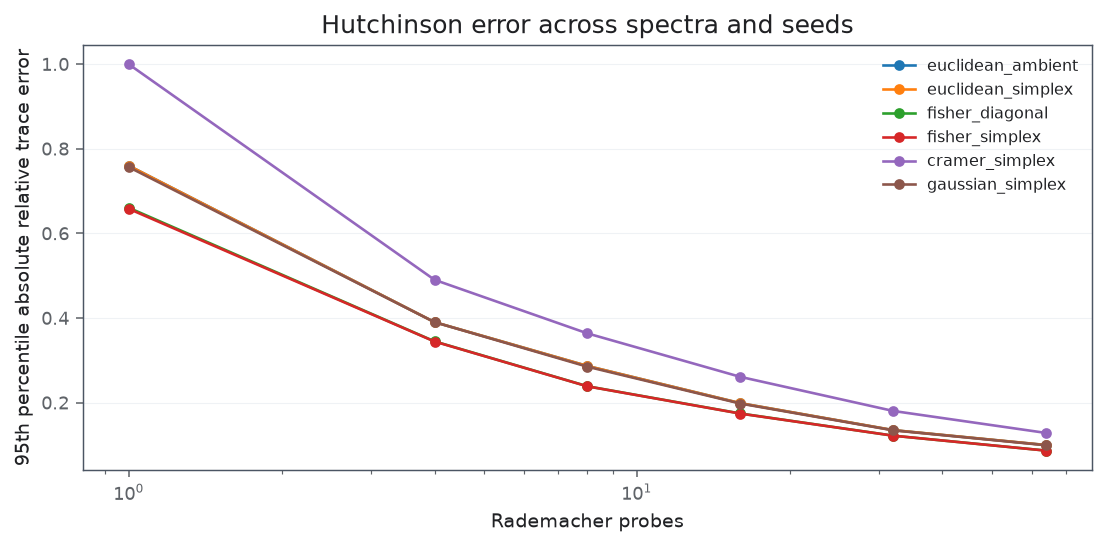

2026-09-05 23:13:50,530 | INFO     | metric_comparison:39 | Library spectral audit completed: angular / euclidean


2026-09-05 23:13:51,001 | INFO     | metric_comparison:39 | Library spectral audit completed: angular / fisher_rao


2026-09-05 23:13:51,465 | INFO     | metric_comparison:39 | Library spectral audit completed: canonical_u / euclidean


2026-09-05 23:13:51,940 | INFO     | metric_comparison:39 | Library spectral audit completed: canonical_u / fisher_rao


mean    median       min       max
output_space geometry                                          
angular      euclidean  -0.079030 -0.033383 -0.552584 -0.000039
             fisher_rao -0.105944 -0.071315 -0.541003 -0.000224
canonical_u  euclidean  -0.079030 -0.033383 -0.552584 -0.000039
             fisher_rao -0.105944 -0.071315 -0.541003 -0.000224

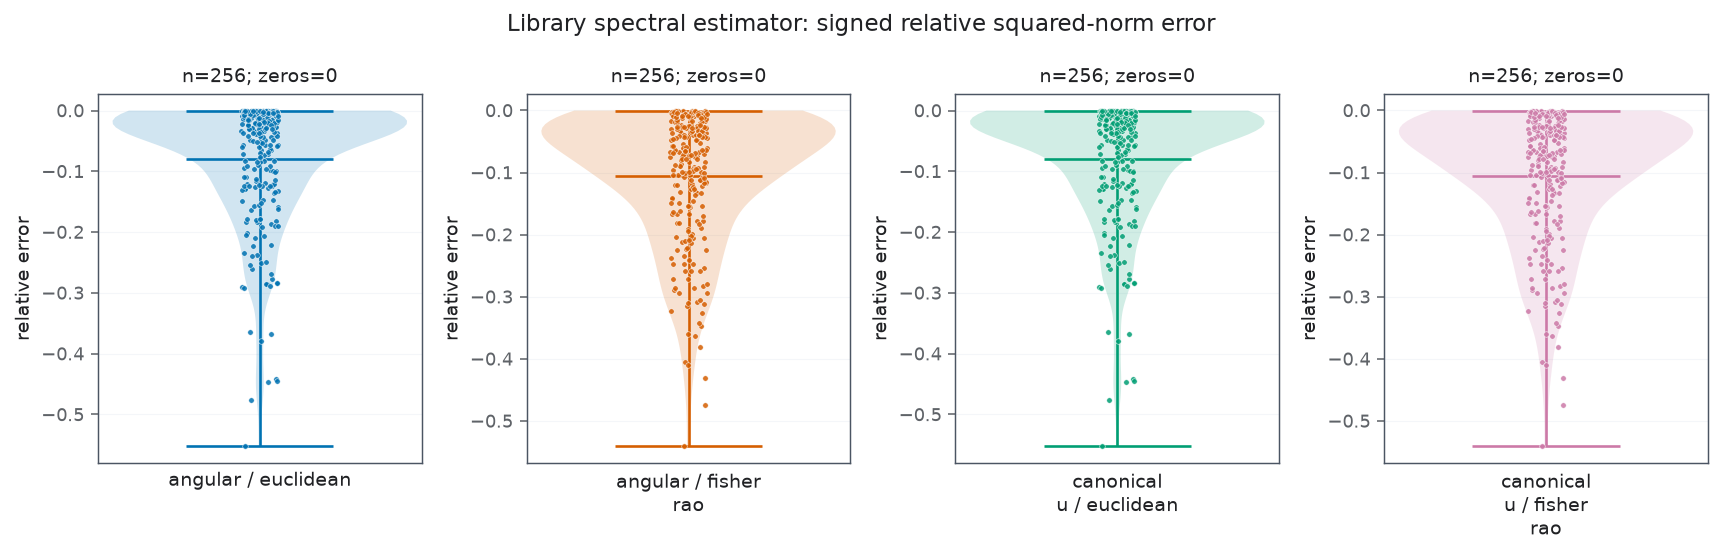

In [8]:
hutchinson_rows = []
for name, gram in angular_grams.items():
    exact_trace = gram.diagonal(dim1=-2, dim2=-1).sum(dim=1)  # (N,)
    for repeat in range(ESTIMATOR_REPEATS):
        generator = torch.Generator().manual_seed(RANDOM_SEED + 200 + repeat)
        probes = torch.randint(2, (len(sample_ids), max(PROBE_COUNTS), gram.shape[-1]), generator=generator).double()*2-1  # (N, P, D)
        probe_values = torch.einsum("npd,ndk,npk->np", probes, gram, probes)  # (N, P)
        for count in PROBE_COUNTS:
            estimate = probe_values[:, :count].mean(dim=1)  # (N,)
            relative = torch.where(exact_trace > 0, (estimate-exact_trace)/exact_trace, torch.nan)
            for spectrum_id, error in zip(sample_ids, relative.numpy()):
                hutchinson_rows.append({"spectrum_id": int(spectrum_id), "geometry": name, "repeat": repeat, "probes": count, "relative_error": error})
hutchinson_frame = pd.DataFrame(hutchinson_rows)
hutchinson_summary = hutchinson_frame.groupby(["geometry", "probes"]).relative_error.agg(
    median="median", mean="mean", q95_absolute=lambda values: np.nanquantile(np.abs(values), .95))
display(hutchinson_summary)
fig, ax = plt.subplots(figsize=(8, 4))
for name in GEOMETRIES:
    ax.plot(PROBE_COUNTS, hutchinson_summary.loc[name].q95_absolute, marker="o", label=name)
ax.set(xscale="log", xlabel="Rademacher probes", ylabel="95th percentile absolute relative trace error", title="Hutchinson error across spectra and seeds")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

power_rows = []
for output_space, output_map, reference in (("angular", encode_direction, spectral_wide), ("canonical_u", encode_canonical, u_wide)):
    for geometry_name, exact_name in (("euclidean", "euclidean_ambient"), ("fisher_rao", "fisher_simplex")):
        adapter = SensitivityDiagnostic(output_map, geometry_name)
        for repeat in range(ESTIMATOR_REPEATS):
            with torch.random.fork_rng(devices=[device.index or 0] if device.type == "cuda" else []):
                torch.manual_seed(RANDOM_SEED + 300 + repeat)
                batch = sample_spectra[:POWER_AUDIT_SIZE].to(device).clone().requires_grad_(True)
                estimates = adapter.estimate_spectral_squared(model, batch).cpu().numpy()  # (A,)
            exact = reference[exact_name].iloc[:len(estimates)].to_numpy()**2
            for spectrum_id, value, target in zip(sample_ids, estimates, exact):
                power_rows.append({"spectrum_id": int(spectrum_id), "output_space": output_space, "geometry": geometry_name,
                                   "repeat": repeat, "estimate": value, "exact": target,
                                   "relative_error": (value-target)/target if target > 0 else np.nan})
        logger.info("Library spectral audit completed: %s / %s", output_space, geometry_name)
power_frame = pd.DataFrame(power_rows)
display(power_frame.groupby(["output_space", "geometry"]).relative_error.agg(["mean", "median", "min", "max"]))
distribution_panels({f"{space} / {name}": group.relative_error for (space, name), group in power_frame.groupby(["output_space", "geometry"])},
                    "Library spectral estimator: signed relative squared-norm error", "relative error")

## Finite perturbations and local linearization

`mz_shift` shifts one bin to the right with zero fill, **without circular wraparound**, then restores TIC. The discarded boundary mass is recorded. `width_jitter` is deterministic Gaussian broadening with an extra sigma of one bin; it is a discrete smoothing experiment, not a verified instrument model. Zero-padding losses are recorded before TIC normalization. Multiplicative lognormal noise (sigma 0.05 per bin) and clipped additive noise (sigma 0.02 times each spectrum's mean intensity) are repeated with independent fixed seeds.

All $T(x)$ preserve nonnegativity and unit TIC after preprocessing. Define $\delta=T(x)-x$ **after** that preprocessing and evaluate $x_t=x+t\delta$. The directional first-order prediction is $t\|J_q\delta\|$ in radians. The observed angle is measured from $q(x)$ to $q(x_t)$. Only their small-$t$ agreement tests linearization; a correlation between a worst-direction norm and a full one-bin shift does not.

The perturbation amplitudes of different families are not physically matched. Their raw angle magnitudes must not be interpreted as a ranking of real-world prevalence or importance. No Fisher-local length is computed for support-changing directions.

2026-09-05 23:13:53,008 | INFO     | metric_comparison:57 | Transform diagnostics completed: mz_shift (1 repeats)


2026-09-05 23:13:53,552 | INFO     | metric_comparison:57 | Transform diagnostics completed: width_jitter (1 repeats)


2026-09-05 23:13:57,458 | INFO     | metric_comparison:57 | Transform diagnostics completed: intensity_lognormal (8 repeats)


2026-09-05 23:14:00,910 | INFO     | metric_comparison:57 | Transform diagnostics completed: additive_noise (8 repeats)


Zero-amplitude angular residual: 0 radians


,transform,n,nonfinite,zeros,q25,median,q75,q90,q95,q99,mean,std,iqr,min,max,median_ci_low,median_ci_high,q95_ci_low,q95_ci_high
0,mz_shift,300,0,0,20.650223,29.035524,36.235951,44.168788,46.716565,50.570594,28.864073,10.731100,15.585728,5.885968,53.170944,27.218857,30.427825,45.650721,48.006364
1,width_jitter,300,0,0,9.250874,11.072386,14.410577,16.494286,18.067106,19.223613,11.808470,3.439472,5.159704,5.038146,21.625791,10.635811,11.715532,17.340191,18.648156
2,intensity_lognormal,300,0,0,0.591719,0.779246,0.996129,1.161941,1.242305,1.447765,0.811489,0.252897,0.404410,0.401397,1.508589,0.738086,0.826883,1.189594,1.348808
3,additive_noise,300,0,0,0.068636,0.081684,0.112722,0.131852,0.141190,0.161460,0.091126,0.028339,0.044086,0.047536,0.205157,0.076742,0.088452,0.133959,0.145659


boundary_mass_lost           introduced_mass            \
                                  mean       max            mean       max   
transform                                                                    
additive_noise                0.000000  0.000000        0.004110  0.008393   
intensity_lognormal           0.000000  0.000000        0.000000  0.000000   
mz_shift                      0.000062  0.000751        0.490285  1.000000   
width_jitter                  0.000189  0.000906        0.268490  0.632789   

                     input_l2            
                         mean       max  
transform                                
additive_noise       0.000960  0.002059  
intensity_lognormal  0.006058  0.022383  
mz_shift             0.179675  0.368018  
width_jitter         0.091370  0.186696

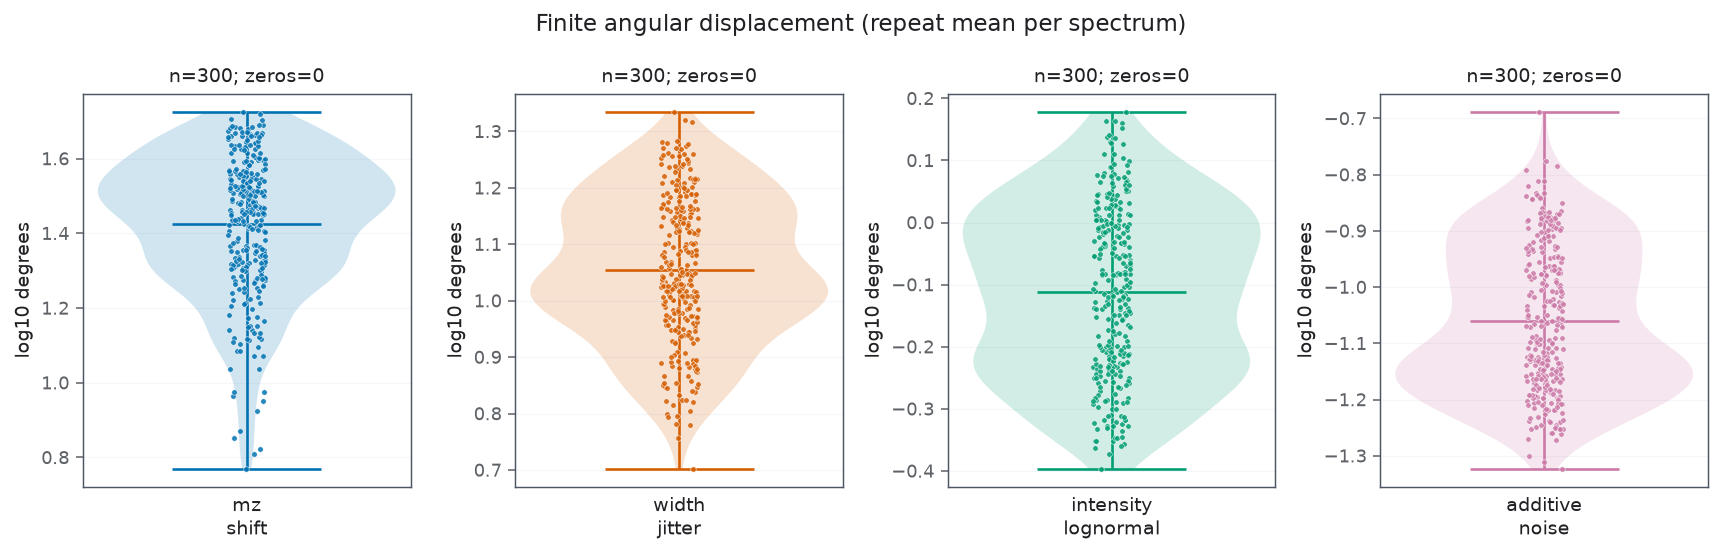

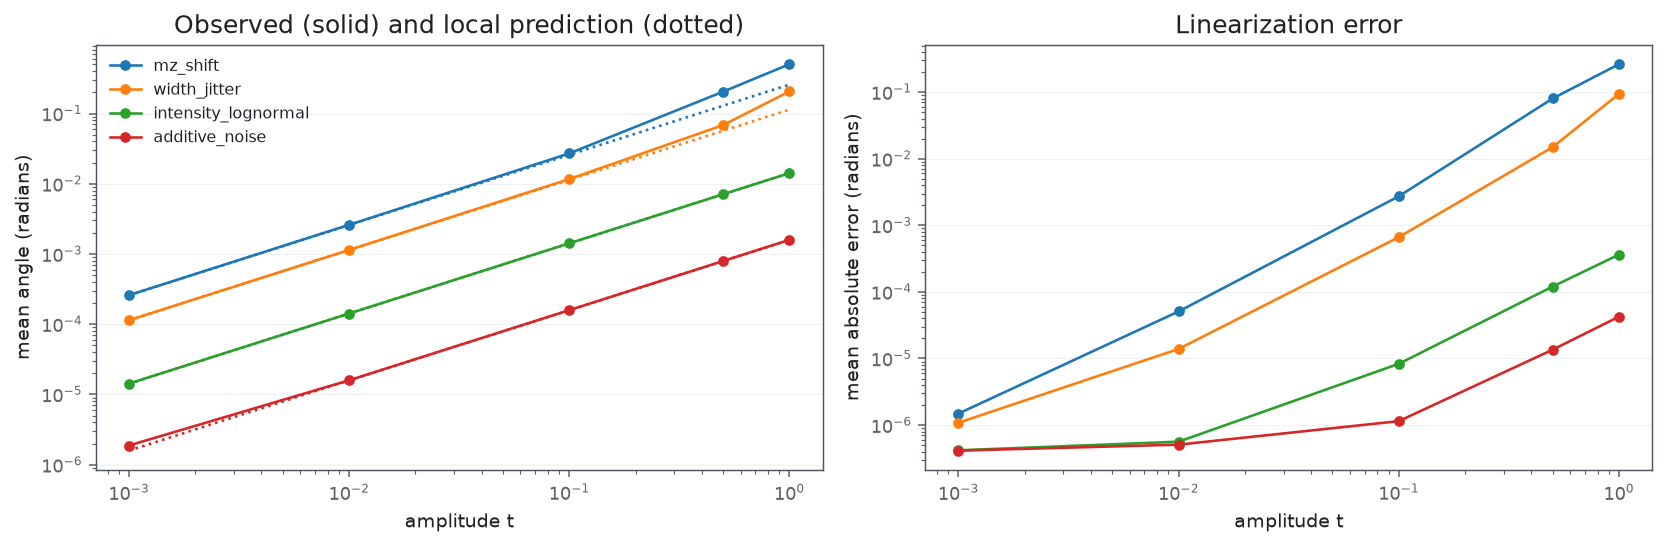

actual_radians  predicted_radians
transform           amplitude                                   
additive_noise      0.000            0.000000           0.000000
                    0.001            0.000002           0.000001
                    0.010            0.000015           0.000014
                    0.100            0.000145           0.000145
                    0.500            0.000728           0.000724
                    1.000            0.001460           0.001449
intensity_lognormal 0.000            0.000000           0.000000
                    0.001            0.000013           0.000013
                    0.010            0.000126           0.000126
                    0.100            0.001265           0.001264
                    0.500            0.006329           0.006318
                    1.000            0.012623           0.012636
mz_shift            0.000            0.000000           0.000000
                    0.001            0.000246           0.000247
                    0.010            0.002487           0.002467
                    0.100            0.025851           0.024674
                    0.500            0.201691           0.123371
                    1.000            0.506765           0.246742
width_jitter        0.000            0.000000           0.000000
                    0.001            0.000106           0.000106
                    0.010            0.001059           0.001058
                    0.100            0.010955           0.010581
                    0.500            0.066450           0.052904
                    1.000            0.193250           0.105809

In [9]:
def normalize_tic(x):
    """Restore TIC without introducing mass into empty bins."""
    totals = x.sum(dim=1, keepdim=True)  # (B, 1)
    if torch.any(totals <= 0):
        raise ValueError("Perturbation removed all spectrum mass.")
    return x / totals


def transform_spectra(x, name, repeat):
    """Return a normalized transform and boundary mass lost before normalization."""
    generator = torch.Generator(device="cpu").manual_seed(RANDOM_SEED + 400 + repeat)
    lost = torch.zeros(x.shape[0], device=x.device)
    if name == "mz_shift":
        transformed = torch.zeros_like(x)
        transformed[:, 1:] = x[:, :-1]
        lost = x[:, -1]  # (B,)
    elif name == "width_jitter":
        kernel = gaussian_kernel_for(np.sqrt(gaussian_sigma_bins**2 + 1.0)).to(x)
        transformed = F.conv1d(x[:, None, :], kernel[None, None, :], padding=kernel.numel()//2).squeeze(1)  # (B, M)
        lost = x.sum(dim=1) - transformed.sum(dim=1)  # (B,)
    else:
        noise = torch.randn(x.shape, generator=generator).to(x)
        if name == "intensity_lognormal":
            transformed = x * torch.exp(.05 * noise)
        elif name == "additive_noise":
            transformed = (x + .02 * x.mean(dim=1, keepdim=True) * noise).clamp_min(0)
        else:
            raise ValueError(name)
    return normalize_tic(transformed), lost


TRANSFORMS = ("mz_shift", "width_jitter", "intensity_lognormal", "additive_noise")
transform_rows, linearization_rows = [], []
x = sample_spectra.to(device)
for name in TRANSFORMS:
    repeats = TRANSFORM_REPEATS if name in {"intensity_lognormal", "additive_noise"} else 1
    for repeat in range(repeats):
        transformed, lost = transform_spectra(x, name, repeat)
        delta = (transformed-x).double().cpu()  # (N, M)
        prediction = torch.linalg.vector_norm(torch.einsum("ndm,nm->nd", angular_jacobian, delta), dim=1).numpy()  # (N,)
        for amplitude in AMPLITUDES:
            direction_batches = []
            with torch.no_grad():
                for start in range(0, len(x), BATCH_SIZE):
                    perturbed = x[start:start+BATCH_SIZE] + amplitude*(transformed[start:start+BATCH_SIZE]-x[start:start+BATCH_SIZE])
                    direction_batches.append(encode_direction(perturbed))
            actual = paired_direction_angles(baseline_q, torch.cat(direction_batches)).cpu().numpy()  # (N,)
            predicted = amplitude * prediction
            for index, spectrum_id in enumerate(sample_ids):
                linearization_rows.append({"spectrum_id": int(spectrum_id), "transform": name, "repeat": repeat,
                                           "amplitude": amplitude, "actual_radians": actual[index], "predicted_radians": predicted[index]})
                if amplitude == 1:
                    transform_rows.append({"spectrum_id": int(spectrum_id), "transform": name, "repeat": repeat,
                                           "angle_degrees": np.degrees(actual[index]), "boundary_mass_lost": float(lost[index]),
                                           "input_l2": float(delta[index].norm()),
                                           "introduced_mass": float(transformed[index][x[index] == 0].sum())})
    logger.info("Transform diagnostics completed: %s (%s repeats)", name, repeats)
transform_frame = pd.DataFrame(transform_rows)
linearization_frame = pd.DataFrame(linearization_rows)
zero_amplitude_max = linearization_frame.query("amplitude == 0").actual_radians.max()
print(f"Zero-amplitude angular residual: {zero_amplitude_max:.3g} radians")
if zero_amplitude_max > 1e-6:
    raise ValueError("Zero-amplitude perturbation exceeds float32 angular tolerance.")
# Repeat averages preserve the spectrum as the sampling unit in comparisons and bootstrap.
transform_means = transform_frame.groupby(["spectrum_id", "transform"]).angle_degrees.mean().unstack().reindex(sample_ids)
transform_summary = pd.DataFrame([{ "transform": name, **distribution_summary(transform_means[name])} for name in TRANSFORMS])
display(transform_summary)
display(transform_frame.groupby("transform")[["boundary_mass_lost", "introduced_mass", "input_l2"]].agg(["mean", "max"]))
distribution_panels({name: transform_means[name] for name in TRANSFORMS}, "Finite angular displacement (repeat mean per spectrum)", "degrees", logarithmic=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name in TRANSFORMS:
    group = linearization_frame.query("transform == @name and amplitude > 0").copy()
    group["absolute_error_radians"] = abs(group.actual_radians-group.predicted_radians)
    mean_by_amplitude = group.groupby("amplitude")[["actual_radians", "predicted_radians", "absolute_error_radians"]].mean()
    axes[0].plot(mean_by_amplitude.index, mean_by_amplitude.actual_radians, marker="o", label=name)
    axes[0].plot(mean_by_amplitude.index, mean_by_amplitude.predicted_radians, linestyle=":", color=axes[0].lines[-1].get_color())
    axes[1].plot(mean_by_amplitude.index, mean_by_amplitude.absolute_error_radians, marker="o", label=name)
axes[0].set(xscale="log", yscale="log", xlabel="amplitude t", ylabel="mean angle (radians)", title="Observed (solid) and local prediction (dotted)")
axes[1].set(xscale="log", yscale="log", xlabel="amplitude t", ylabel="mean absolute error (radians)", title="Linearization error")
axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()
display(linearization_frame.groupby(["transform", "amplitude"])[["actual_radians", "predicted_radians"]].median())

## Does the corrected metric track finite transform sensitivity?

Both Frobenius and spectral rankings are checked against **each** transform. Paired bootstrap resamples the same spectrum IDs for all candidate metrics and uses per-spectrum means for stochastic transforms. The confidence interval for the **difference** from Euclidean-simplex correlation is more relevant than comparing two independently reported intervals. These exploratory intervals do not correct for multiple comparisons or spatial dependence.

The primary predeclared contrast is Fisher-simplex spectral versus Euclidean-simplex spectral for `mz_shift`. Positive correlation alone is not proof that this regularizer will improve the trained model. Gaussian/Cramer are secondary controls. Claims about a statistical tie or a decisive winner must be supported by the paired interval, not rounded correlation values.

,transform,statistic,geometry,rho,ci_low,ci_high,delta_rho,delta_ci_low,delta_ci_high,valid_bootstraps
0,mz_shift,spectral,euclidean_ambient,0.502693,0.416075,0.577829,0.000000,0.000000,0.000000,1000
1,mz_shift,spectral,euclidean_simplex,0.502693,0.416075,0.577829,0.000000,0.000000,0.000000,1000
2,mz_shift,spectral,fisher_diagonal,0.705172,0.627244,0.769975,0.202479,0.113881,0.284348,1000
3,mz_shift,spectral,fisher_simplex,0.704907,0.627645,0.769215,0.202214,0.112926,0.283849,1000
4,mz_shift,spectral,cramer_simplex,0.032333,-0.077169,0.135968,-0.470360,-0.550977,-0.384527,1000
5,mz_shift,spectral,gaussian_simplex,0.537970,0.453145,0.610935,0.035276,0.020885,0.049584,1000
6,mz_shift,frobenius,euclidean_ambient,0.667269,0.601734,0.723512,0.000000,0.000000,0.000000,1000
7,mz_shift,frobenius,euclidean_simplex,0.667269,0.601734,0.723512,0.000000,0.000000,0.000000,1000
8,mz_shift,frobenius,fisher_diagonal,0.797048,0.735812,0.842375,0.129779,0.064028,0.197936,1000
9,mz_shift,frobenius,fisher_simplex,0.797305,0.736270,0.842532,0.130036,0.064248,0.198313,1000


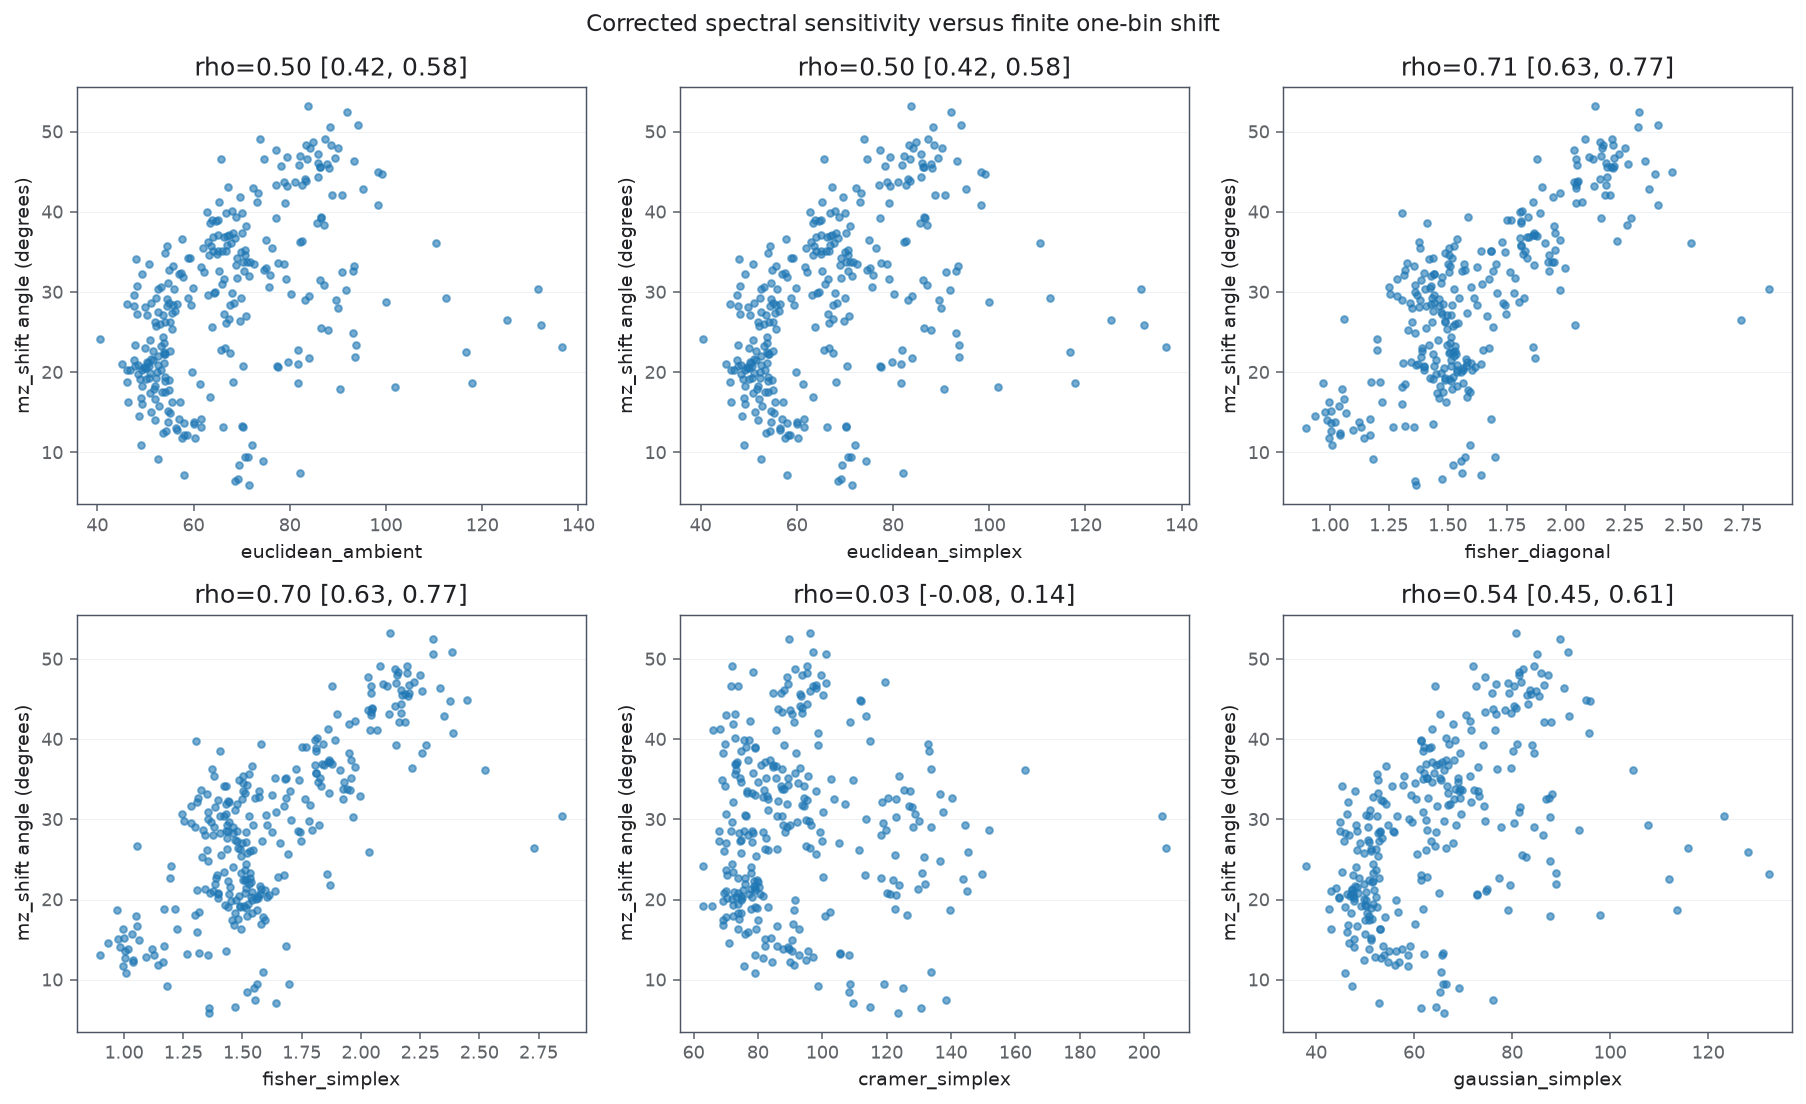

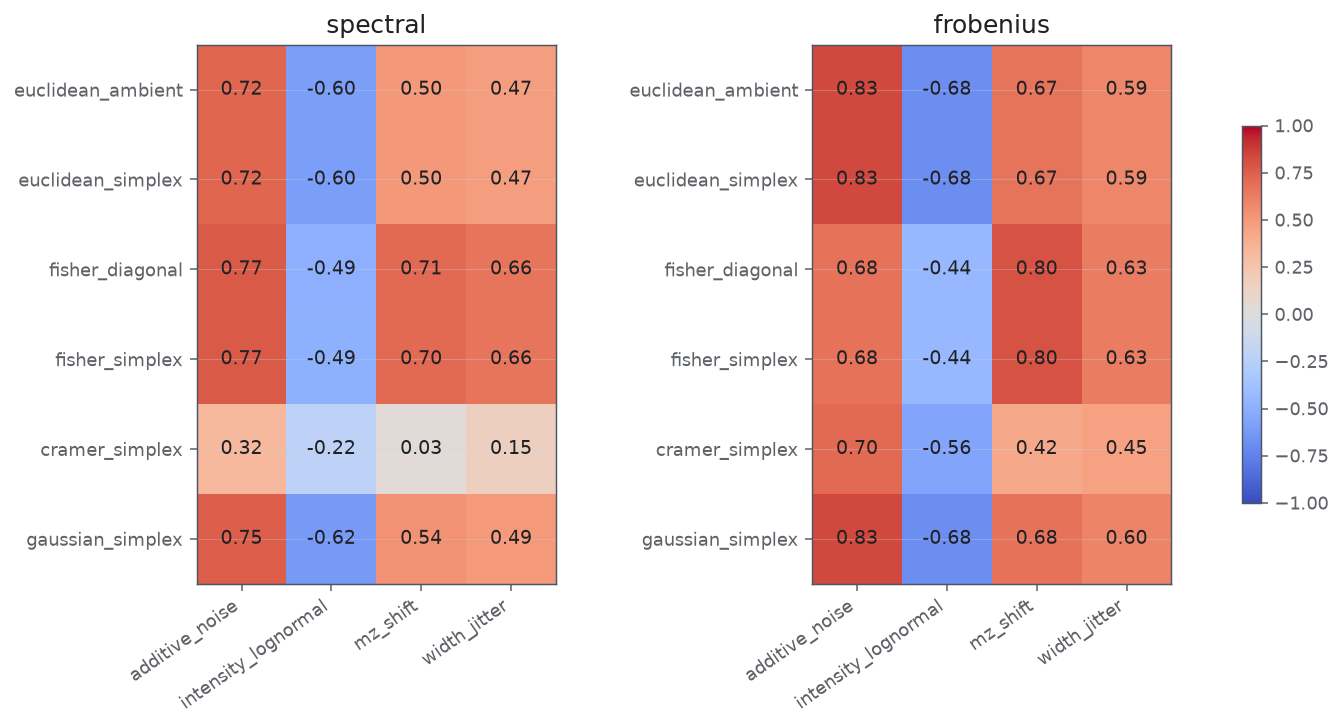

In [10]:
correlation_rows = []
bootstrap_rng = np.random.default_rng(RANDOM_SEED + 500)
bootstrap_indices = bootstrap_rng.integers(len(sample_ids), size=(BOOTSTRAP_REPLICATES, len(sample_ids)))
for transform in TRANSFORMS:
    angles = transform_means[transform].to_numpy()
    for statistic, frame in (("spectral", spectral_wide), ("frobenius", frobenius_wide)):
        reference = frame.euclidean_simplex.to_numpy()
        reference_bootstrap = np.array([spearmanr(reference[ids], angles[ids]).statistic for ids in bootstrap_indices])
        for name in GEOMETRIES:
            values = frame[name].to_numpy()
            boot = np.array([spearmanr(values[ids], angles[ids]).statistic for ids in bootstrap_indices])
            valid = np.isfinite(boot) & np.isfinite(reference_bootstrap)
            low, high = np.quantile(boot[valid], [.025, .975]) if valid.any() else (np.nan, np.nan)
            diff_low, diff_high = np.quantile((boot-reference_bootstrap)[valid], [.025, .975]) if valid.any() else (np.nan, np.nan)
            correlation_rows.append({"transform": transform, "statistic": statistic, "geometry": name,
                                     "rho": spearmanr(values, angles).statistic, "ci_low": low, "ci_high": high,
                                     "delta_rho": spearmanr(values, angles).statistic-spearmanr(reference, angles).statistic,
                                     "delta_ci_low": diff_low, "delta_ci_high": diff_high, "valid_bootstraps": int(valid.sum())})
correlation_frame = pd.DataFrame(correlation_rows)
display(correlation_frame)
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for name, ax in zip(GEOMETRIES, axes.flat):
    ax.scatter(spectral_wide[name], transform_means.mz_shift, s=12, alpha=.6)
    result = correlation_frame.query("transform == 'mz_shift' and statistic == 'spectral' and geometry == @name").iloc[0]
    ax.set(xlabel=name, ylabel="mz_shift angle (degrees)", title=f"rho={result.rho:.2f} [{result.ci_low:.2f}, {result.ci_high:.2f}]")
fig.suptitle("Corrected spectral sensitivity versus finite one-bin shift")
fig.tight_layout()
plt.show()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for index, statistic in enumerate(("spectral", "frobenius")):
    matrix = correlation_frame.query("statistic == @statistic").pivot(index="geometry", columns="transform", values="rho").reindex(GEOMETRIES)
    im = axes[index].imshow(matrix, vmin=-1, vmax=1, cmap="coolwarm")
    axes[index].set(xticks=range(len(matrix.columns)), xticklabels=matrix.columns, yticks=range(len(matrix)), yticklabels=matrix.index, title=statistic)
    plt.setp(axes[index].get_xticklabels(), rotation=35, ha="right")
    for row in range(len(matrix)):
        for col in range(len(matrix.columns)):
            axes[index].text(col, row, f"{matrix.iloc[row,col]:.2f}", ha="center", va="center")
fig.colorbar(im, ax=axes, shrink=.7)
plt.show()

## Frozen thresholds and initial weight calibration

Set $\tau_g=Q_{0.95}(s_g)$ once on this baseline validation sample. For the proposed shape, $P_g=s_g^2+\alpha[s_g-\tau_g]_+^2$, with $\alpha=1$. The threshold applies to the **norm**, not its square. Its empirical activation is reported explicitly. It remains fixed during later training and evaluation.

The historical reference is Euclidean ambient spectral on **canonical-u**, with a provisional weight $\lambda_{E,ref}=10^{-5}$. For a target penalty $P_g$, match batch-mean loss scale:

$$\lambda_{g,0}=\lambda_{E,ref}\frac{\operatorname{mean}(s_{E,u}^2)}{\operatorname{mean}(P_g)}.$$

The median-based alternative is a robustness diagnostic, not the same formula. Matching loss values does not match parameter gradients. The exact reference also differs from a finite-iteration training estimator; the audit quantifies that additional approximation.

**Configuration compatibility:** current `ContractiveLoss(penalized_space="u")` regularizes $J_u$, not $J_q$. Its Fisher input projection is correct. Therefore **angular thresholds and weights must not be pasted into that configuration** until its output map also becomes angular. The notebook exports separate angular and canonical-u records with explicit compatibility labels; it does not edit training YAML. Euclidean-simplex is another diagnostic geometry not exposed by the current training loss.

Legacy `hinged` remains $[F^2-\tau^2]_+$ and is not used to calibrate the new combined spectral penalty. The old inverse threshold scaling and its numerical conclusions have been removed.

,output_space,input_geometry,penalty_shape,tau,tau_ci_low,tau_ci_high,hinge_quantile,hinge_alpha,active_fraction_at_tau,mean_penalty,hinge_fraction_of_combined_mean,lambda_0,lambda_0_ci_low,lambda_0_ci_high,lambda_median_alternative,lambda_low,lambda_high,current_training_api_compatible
0,angular,euclidean_ambient,spectral,NaN,NaN,NaN,0.95,0.0,0.05,4895.061979,0.005176,0.000100,0.000100,0.000100,0.000100,0.000033,0.000300,False
1,angular,euclidean_ambient,spectral_plus_hinged,93.787608,90.987342,101.810122,0.95,1.0,0.05,4920.528365,0.005176,0.000099,0.000099,0.000100,0.000100,0.000033,0.000298,False
2,angular,euclidean_simplex,spectral,NaN,NaN,NaN,0.95,0.0,0.05,4895.061979,0.005176,0.000100,0.000100,0.000100,0.000100,0.000033,0.000300,False
3,angular,euclidean_simplex,spectral_plus_hinged,93.787608,90.987342,101.810122,0.95,1.0,0.05,4920.528365,0.005176,0.000099,0.000099,0.000100,0.000100,0.000033,0.000298,False
4,angular,fisher_simplex,spectral,NaN,NaN,NaN,0.95,0.0,0.05,2.758698,0.001092,0.177441,0.169095,0.187082,0.183406,0.059147,0.532322,False
5,angular,fisher_simplex,spectral_plus_hinged,2.225414,2.173400,2.307819,0.95,1.0,0.05,2.761713,0.001092,0.177247,0.168910,0.186852,0.183406,0.059082,0.531741,False
6,canonical_u,euclidean_ambient,spectral,NaN,NaN,NaN,0.95,0.0,0.05,48950.549749,0.005176,0.000010,0.000010,0.000010,0.000010,0.000003,0.000030,True
7,canonical_u,euclidean_ambient,spectral_plus_hinged,296.582197,287.726949,321.951566,0.95,1.0,0.05,49205.212897,0.005176,0.000010,0.000010,0.000010,0.000010,0.000003,0.000030,True
8,canonical_u,euclidean_simplex,spectral,NaN,NaN,NaN,0.95,0.0,0.05,48950.549749,0.005176,0.000010,0.000010,0.000010,0.000010,0.000003,0.000030,False
9,canonical_u,euclidean_simplex,spectral_plus_hinged,296.582197,287.726949,321.951566,0.95,1.0,0.05,49205.212897,0.005176,0.000010,0.000010,0.000010,0.000010,0.000003,0.000030,False


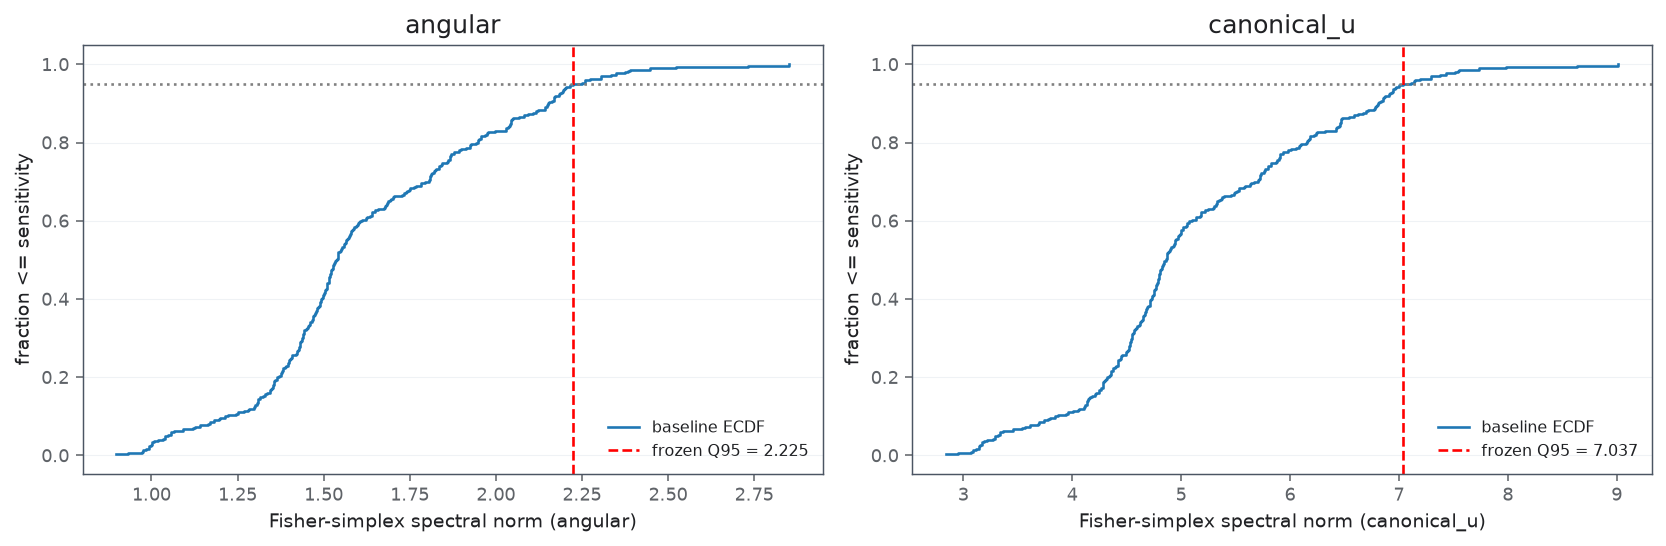

,output_space,ratio_of_means,ratio_of_medians,median_of_paired_ratios
0,angular,0.000056,0.000055,0.000067
1,canonical_u,0.000564,0.000545,0.000674


In [11]:
reference_penalty = u_wide.euclidean_ambient.to_numpy()**2
calibration_rows = []
for output_space, frame in (("angular", spectral_wide), ("canonical_u", u_wide)):
    for name in ("euclidean_ambient", "euclidean_simplex", "fisher_simplex"):
        sensitivity = frame[name].to_numpy()
        threshold = float(np.quantile(sensitivity, HINGE_QUANTILE))
        threshold_interval = np.quantile(np.quantile(sensitivity[bootstrap_indices], HINGE_QUANTILE, axis=1), [.025, .975])
        hinge = np.maximum(sensitivity-threshold, 0)**2
        for shape, penalty in (("spectral", sensitivity**2), ("spectral_plus_hinged", sensitivity**2+HINGE_ALPHA*hinge)):
            if penalty.mean() <= 0 or not np.isfinite(penalty).all():
                raise ValueError("Cannot calibrate a zero or nonfinite penalty.")
            weight = LAMBDA_REFERENCE * reference_penalty.mean()/penalty.mean()
            med_weight = LAMBDA_REFERENCE*np.median(reference_penalty)/np.median(penalty) if np.median(penalty) > 0 else np.nan
            compatible = output_space == "canonical_u" and name in {"euclidean_ambient", "fisher_simplex"}
            bootstrap_weights = np.array([LAMBDA_REFERENCE*reference_penalty[ids].mean()/penalty[ids].mean() for ids in bootstrap_indices])
            calibration_rows.append({"output_space": output_space, "input_geometry": name, "penalty_shape": shape,
                                     "tau": threshold if shape == "spectral_plus_hinged" else None,
                                     "tau_ci_low": threshold_interval[0] if shape == "spectral_plus_hinged" else None,
                                     "tau_ci_high": threshold_interval[1] if shape == "spectral_plus_hinged" else None,
                                     "hinge_quantile": HINGE_QUANTILE, "hinge_alpha": HINGE_ALPHA if shape == "spectral_plus_hinged" else 0.,
                                     "active_fraction_at_tau": float(np.mean(sensitivity > threshold)),
                                     "mean_penalty": float(penalty.mean()), "hinge_fraction_of_combined_mean": float((HINGE_ALPHA*hinge).mean()/(sensitivity**2+HINGE_ALPHA*hinge).mean()),
                                     "lambda_0": weight, "lambda_0_ci_low": np.quantile(bootstrap_weights,.025), "lambda_0_ci_high": np.quantile(bootstrap_weights,.975),
                                     "lambda_median_alternative": med_weight, "lambda_low": weight/3, "lambda_high": weight*3,
                                     "current_training_api_compatible": compatible})
calibration_frame = pd.DataFrame(calibration_rows)
display(calibration_frame)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for output_space, frame, ax in zip(("angular", "canonical_u"), (spectral_wide, u_wide), axes):
    values = np.sort(frame.fisher_simplex.to_numpy())
    threshold = np.quantile(values, HINGE_QUANTILE)
    ax.step(values, np.arange(1, len(values)+1)/len(values), where="post", label="baseline ECDF")
    ax.axvline(threshold, linestyle="--", color="red", label=f"frozen Q95 = {threshold:.4g}")
    ax.axhline(HINGE_QUANTILE, linestyle=":", color="gray")
    ax.set(xlabel=f"Fisher-simplex spectral norm ({output_space})", ylabel="fraction <= sensitivity", title=output_space)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()
# Paired ratios and ratios of aggregate statistics are deliberately separate.
penalty_scale_summary = pd.DataFrame([
    {"output_space": space, "ratio_of_means": (frame.fisher_simplex**2).mean()/reference_penalty.mean(),
     "ratio_of_medians": np.median(frame.fisher_simplex**2)/np.median(reference_penalty),
     "median_of_paired_ratios": np.nanmedian(np.divide(frame.fisher_simplex.to_numpy()**2, reference_penalty, out=np.full_like(reference_penalty, np.nan), where=reference_penalty>0))}
    for space, frame in (("angular", spectral_wide), ("canonical_u", u_wide))
])
display(penalty_scale_summary)

## Decision record and reproducible artifacts

Use the corrected angular Fisher-simplex distribution and its paired contrast against Euclidean-simplex to judge whether the geometry is worth a training experiment. Inspect the linearization curves before interpreting a finite one-bin shift as a local effect. Inspect the power-iteration error before trusting its tail quantiles during training.

The candidate threshold is a construction rule, not an optimum selected on test. Weight values are initial local-sweep centers, not evidence of a winning regularizer. All exported calibration records identify the output convention. Final model choice still requires training, predictive validation, and finite-shift robustness evaluation.

The following report is generated from the current run; no old correlations or hand-written calibration numbers are retained. Bootstrap intervals do not quantify uncertainty between tissues, images, or training seeds.

In [12]:
primary = correlation_frame.query("transform == 'mz_shift' and statistic == 'spectral' and geometry == 'fisher_simplex'").iloc[0]
if primary.delta_ci_low > 0:
    interpretation = "Positive paired association advantage on this validation sample; training benefit remains untested."
elif primary.delta_ci_high < 0:
    interpretation = "Negative paired association difference on this validation sample."
else:
    interpretation = "Paired interval includes zero; this sample does not resolve a correlation advantage."
print(f"Primary contrast: delta rho={primary.delta_rho:.3f}, conditional 95% CI [{primary.delta_ci_low:.3f}, {primary.delta_ci_high:.3f}].")
print(interpretation)
print("Angular calibration requires an angular output map in training; current penalized_space='u' is a different map.")
print(f"Only {len(sample_ids)*(1-HINGE_QUANTILE):.1f} spectra are expected above Q95; inspect its bootstrap interval.")

frames = {"metrics": metric_frame, "norm_summary": summary_frame, "ratios": ratio_summary,
          "hutchinson_audit": hutchinson_frame, "power_iteration_audit": power_frame,
          "transforms": transform_frame, "linearization": linearization_frame,
          "correlations": correlation_frame, "calibration": calibration_frame,
          "penalty_scales": penalty_scale_summary, "peak_widths": peak_frame}
for name, frame in frames.items():
    frame.to_csv(ARTIFACT_DIR / f"{name}.csv", index=False)
metadata = {"model": MODEL_NAME, "split": CALIBRATION_SPLIT, "sample_ids": sample_ids.tolist(),
            "sample_indices": sample_indices.tolist(), "seed": RANDOM_SEED, "sample_size": len(sample_ids),
            "bootstrap_replicates": BOOTSTRAP_REPLICATES, "estimator_repeats": ESTIMATOR_REPEATS,
            "transform_repeats": TRANSFORM_REPEATS, "amplitudes": list(AMPLITUDES),
            "input_fisher_convention": "diag(x)-xxT; fixed-support boundary limit; no pseudocount",
            "output_angular_convention": "q=center((z-beta)/gamma)/norm(center((z-beta)/gamma)); radians",
            "reference_output": "canonical_u", "lambda_reference": LAMBDA_REFERENCE,
            "hinge_quantile": HINGE_QUANTILE, "hinge_alpha": HINGE_ALPHA,
            "gaussian_sigma_bins": gaussian_sigma_bins, "bin_spacing": BIN_SPACING,
            "torch": torch.__version__, "numpy": np.__version__, "device": str(device),
            "config_sha256": hashlib.sha256(config_path.read_bytes()).hexdigest(),
            "weights_sha256": hashlib.sha256((config_path.parent / "weights.pt").read_bytes()).hexdigest(),
            "git_commit": subprocess.check_output(["git", "rev-parse", "HEAD"], text=True).strip(),
            "criterion_sha256": hashlib.sha256(Path("src/msi_autoencoder_wrapper/training/criterions/autoencoder/regularization/contractive_loss.py").read_bytes()).hexdigest(),
            "diagnostic_sha256": hashlib.sha256(Path("src/msi_autoencoder_wrapper/analysis/autoencoder/latent/sensitivity.py").read_bytes()).hexdigest(),
            "geometry_checks": geometry_report, "primary_contrast_interpretation": interpretation}
(ARTIFACT_DIR / "metadata.json").write_text(json.dumps(metadata, indent=2) + "\n")
(ARTIFACT_DIR / "calibration.json").write_text(calibration_frame.to_json(orient="records", indent=2) + "\n")
logger.info("Diagnostic tables, calibration and provenance written to %s", ARTIFACT_DIR)

Primary contrast: delta rho=0.202, conditional 95% CI [0.113, 0.284].
Positive paired association advantage on this validation sample; training benefit remains untested.
Angular calibration requires an angular output map in training; current penalized_space='u' is a different map.
Only 15.0 spectra are expected above Q95; inspect its bootstrap interval.


2026-09-05 23:14:31,603 | INFO     | metric_comparison:38 | Diagnostic tables, calibration and provenance written to assets/experiments/autoencoder_architecture/notebooks/05_09_26_contractive_expaned/part_0_metric_comparison_results
